In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('../../../../Downloads/mm.csv')

# Create multiple creative visualizations for Km, Kcat, and Vmax
print("Creating creative visualizations for Km, Kcat, and Vmax...")
print(f"Data shape: {df.shape}")
print(f"Motors: {df['Motor'].tolist()}")

# Extract the three features
km = df['Km (µM)'].values
kcat = df['Kcat (ATP/s)'].values
vmax = df['Vmax (nm/s)'].values
motors = df['Motor'].values

df


Creating creative visualizations for Km, Kcat, and Vmax...
Data shape: (11, 4)
Motors: ['HeAl', 'NaGr', 'AdPa', 'Thtr', 'K401', 'Kif5', 'TiLa', 'AcSu', 'Kif3', 'Dipu', 'AcSu2']


,Motor,Km (µM),Kcat (ATP/s),Vmax (nm/s)
0,HeAl,312,407,3260
1,NaGr,155,287,2300
2,AdPa,9,26,206
3,Thtr,84,118,941
4,K401,278,117,933
5,Kif5,138,117,937
6,TiLa,428,253,2022
7,AcSu,448,310,2480
8,Kif3,262,255,2038
9,Dipu,243,242,1938


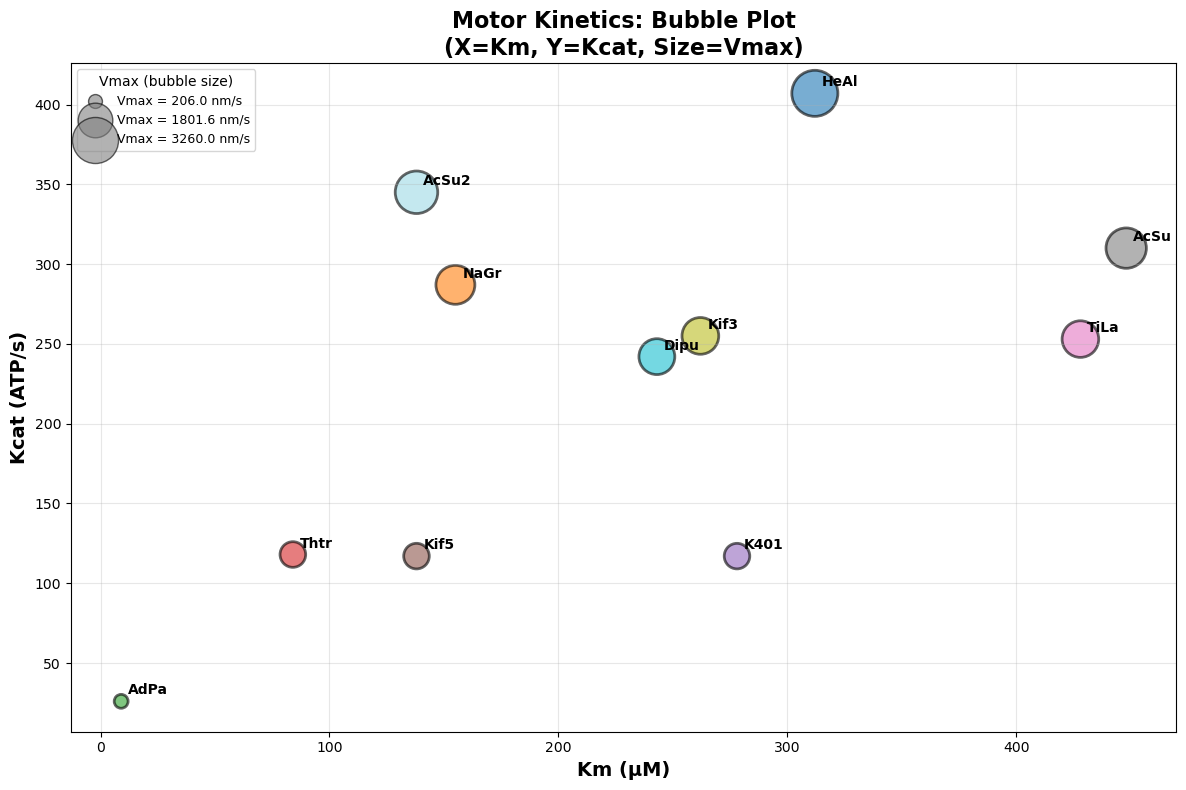

Bubble plot created!


In [3]:
# Option 1: Bubble Plot (2D with size encoding)
# X = Km, Y = Kcat, Size = Vmax, Color = Motor
fig, ax = plt.subplots(figsize=(12, 8))

# Normalize Vmax for bubble sizes (make them visible but not too large)
vmax_normalized = (vmax - vmax.min()) / (vmax.max() - vmax.min())
bubble_sizes = 100 + vmax_normalized * 1000  # Range from 100 to 1100

# Create scatter plot with bubbles
scatter = ax.scatter(km, kcat, s=bubble_sizes, alpha=0.6, 
                     c=range(len(motors)), cmap='tab20', 
                     edgecolors='black', linewidth=2)

# Add labels for each motor
for i, motor in enumerate(motors):
    ax.annotate(motor, (km[i], kcat[i]), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, fontweight='bold')

ax.set_xlabel('Km (µM)', fontsize=14, fontweight='bold')
ax.set_ylabel('Kcat (ATP/s)', fontsize=14, fontweight='bold')
ax.set_title('Motor Kinetics: Bubble Plot\n(X=Km, Y=Kcat, Size=Vmax)', 
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add legend for Vmax (size)
# Create dummy scatter points for legend
sizes_legend = [vmax.min(), vmax.mean(), vmax.max()]
for size_val in sizes_legend:
    size_norm = (size_val - vmax.min()) / (vmax.max() - vmax.min())
    size_scatter = 100 + size_norm * 1000
    ax.scatter([], [], s=size_scatter, c='gray', alpha=0.6, 
               edgecolors='black', label=f'Vmax = {size_val:.1f} nm/s')

ax.legend(title='Vmax (bubble size)', loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print("Bubble plot created!")


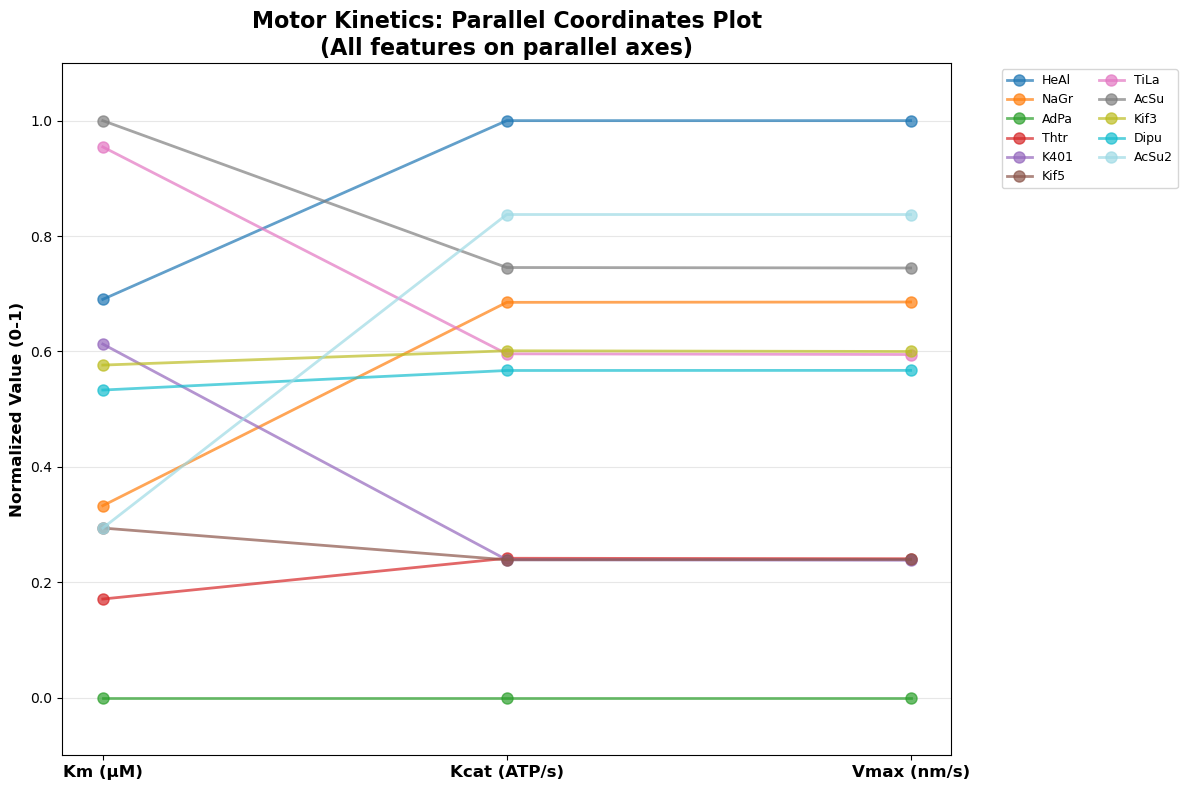

Parallel coordinates plot created!


In [4]:
# Option 2: Parallel Coordinates Plot
# Shows all three features on parallel axes
fig, ax = plt.subplots(figsize=(12, 8))

# Normalize all features to 0-1 scale for parallel coordinates
km_norm = (km - km.min()) / (km.max() - km.min())
kcat_norm = (kcat - kcat.min()) / (kcat.max() - kcat.min())
vmax_norm = (vmax - vmax.min()) / (vmax.max() - vmax.min())

# Create parallel coordinates
x_positions = [0, 1, 2]
feature_names = ['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']

# Plot lines for each motor
colors = plt.cm.tab20(np.linspace(0, 1, len(motors)))
for i, motor in enumerate(motors):
    values = [km_norm[i], kcat_norm[i], vmax_norm[i]]
    ax.plot(x_positions, values, marker='o', linewidth=2, 
            markersize=8, label=motor, color=colors[i], alpha=0.7)

# Set up axes
ax.set_xticks(x_positions)
ax.set_xticklabels(feature_names, fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
ax.set_title('Motor Kinetics: Parallel Coordinates Plot\n(All features on parallel axes)', 
             fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.1, 1.1)

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

print("Parallel coordinates plot created!")


Creating radar plot for all motors...


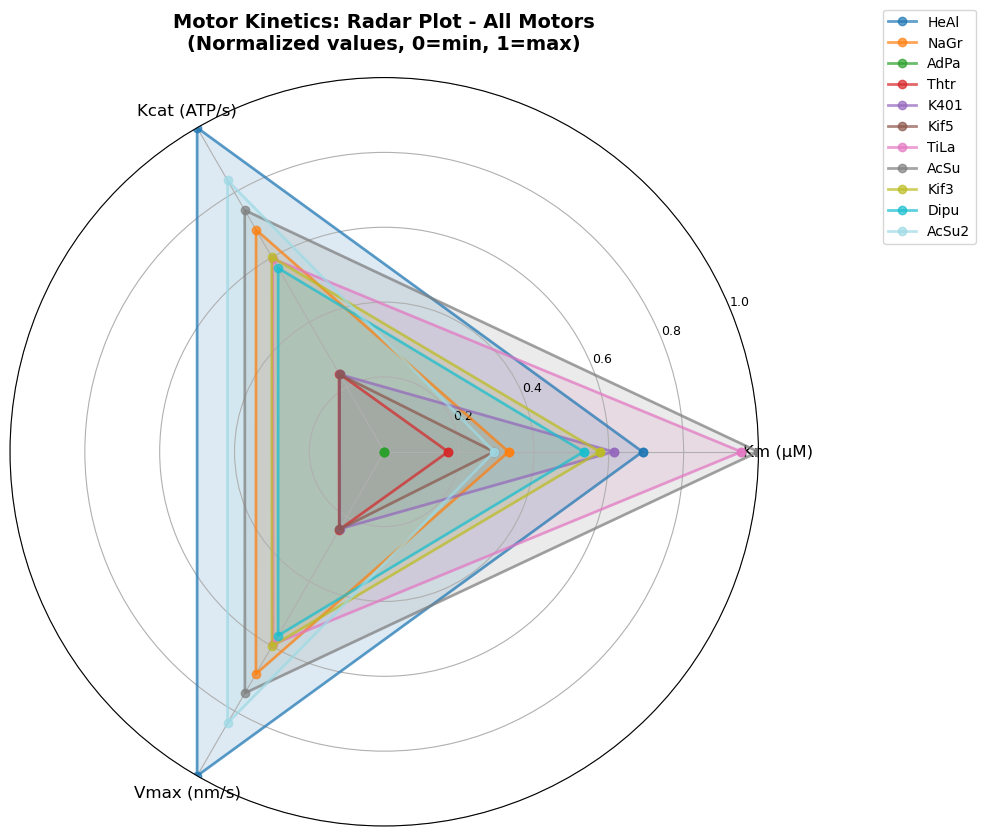

Radar plot created!


In [5]:
# Option 3: Radar/Spider Plot (for individual motors or groups)
from math import pi

# Function to create radar plot
def create_radar_plot(motor_indices, title_suffix=""):
    # Number of variables (features)
    N = 3
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Normalize features to 0-1 scale
    km_norm = (km - km.min()) / (km.max() - km.min())
    kcat_norm = (kcat - kcat.min()) / (kcat.max() - kcat.min())
    vmax_norm = (vmax - vmax.min()) / (vmax.max() - vmax.min())
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Plot each motor
    colors = plt.cm.tab20(np.linspace(0, 1, len(motor_indices)))
    for idx, motor_idx in enumerate(motor_indices):
        values = [km_norm[motor_idx], kcat_norm[motor_idx], vmax_norm[motor_idx]]
        values += values[:1]  # Complete the circle
        
        ax.plot(angles, values, 'o-', linewidth=2, label=motors[motor_idx], 
                color=colors[idx], alpha=0.7)
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    # Customize the plot
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)'], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
    ax.grid(True)
    
    ax.set_title(f'Motor Kinetics: Radar Plot{title_suffix}\n(Normalized values, 0=min, 1=max)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Plot all motors (might be crowded, but shows all)
print("Creating radar plot for all motors...")
create_radar_plot(range(len(motors)), " - All Motors")
print("Radar plot created!")


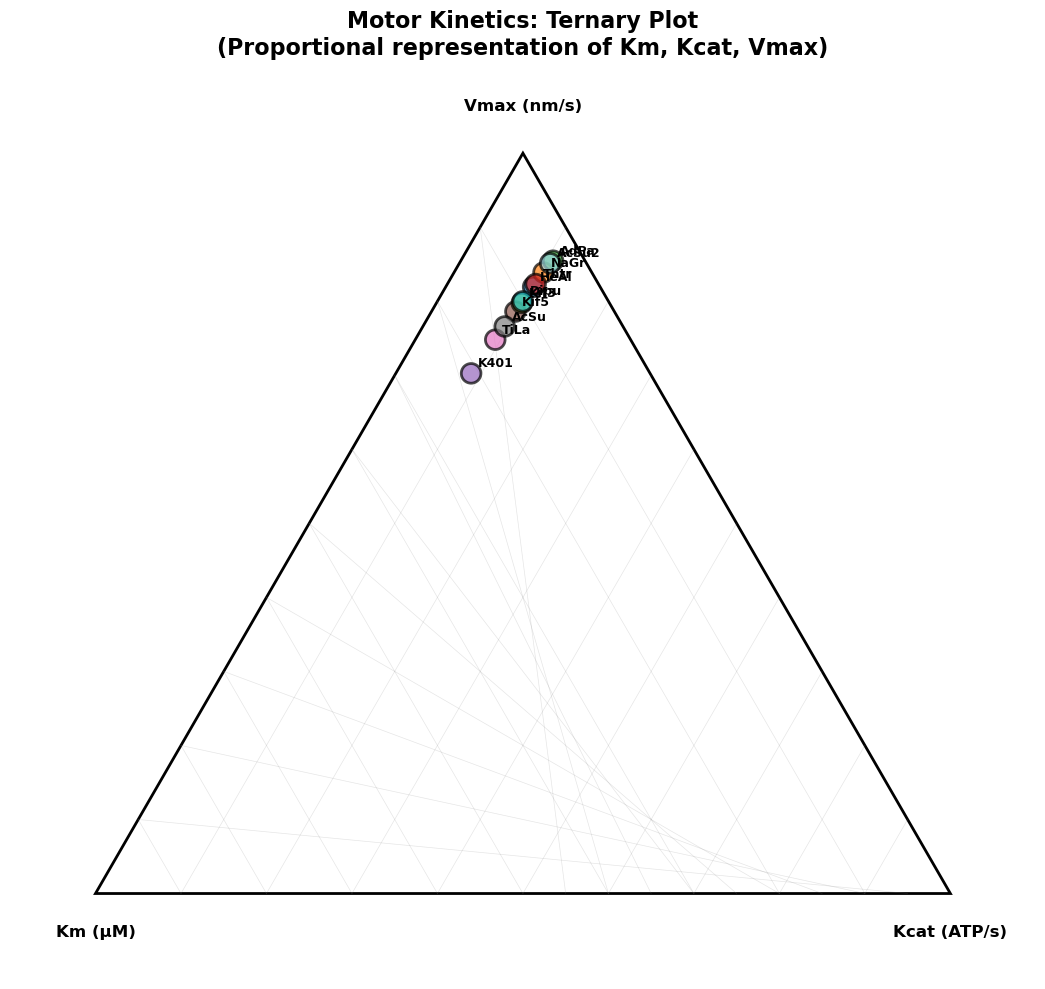

Ternary plot created!


In [6]:
# Option 4: Ternary Plot (Triangle plot)
# Normalize Km, Kcat, Vmax to sum to 1 and plot in triangular coordinates
from matplotlib.patches import Polygon

def ternary_to_cartesian(km_frac, kcat_frac, vmax_frac):
    """Convert ternary coordinates to Cartesian for plotting
    Vertices: Km at (0,0), Kcat at (1,0), Vmax at (0.5, sqrt(3)/2)
    """
    x = 0.5 * (2 * kcat_frac + vmax_frac)
    y = (np.sqrt(3) / 2) * vmax_frac
    return x, y

# Normalize each motor's values to sum to 1 (ternary coordinates)
km_sum = km + kcat + vmax
km_frac = km / km_sum
kcat_frac = kcat / km_sum
vmax_frac = vmax / km_sum

# Convert to Cartesian coordinates
x_coords, y_coords = ternary_to_cartesian(km_frac, kcat_frac, vmax_frac)

# Create ternary plot
fig, ax = plt.subplots(figsize=(12, 10))

# Draw triangle outline
triangle = Polygon([(0, 0), (1, 0), (0.5, np.sqrt(3)/2)], 
                   fill=False, edgecolor='black', linewidth=2)
ax.add_patch(triangle)

# Add labels at triangle vertices
ax.text(0, -0.05, 'Km (µM)', ha='center', fontsize=12, fontweight='bold')
ax.text(1, -0.05, 'Kcat (ATP/s)', ha='center', fontsize=12, fontweight='bold')
ax.text(0.5, np.sqrt(3)/2 + 0.05, 'Vmax (nm/s)', ha='center', 
        fontsize=12, fontweight='bold')

# Plot motors
colors = plt.cm.tab20(np.linspace(0, 1, len(motors)))
scatter = ax.scatter(x_coords, y_coords, s=200, c=colors, 
                     alpha=0.7, edgecolors='black', linewidth=2, zorder=3)

# Add motor labels
for i, motor in enumerate(motors):
    ax.annotate(motor, (x_coords[i], y_coords[i]), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', zorder=4)

# Add grid lines (optional - helps read the plot)
for i in range(1, 10):
    # Lines parallel to each side
    frac = i / 10.0
    # Lines from Km vertex
    ax.plot([frac, 0.5 + 0.5*frac], [0, np.sqrt(3)/2 * (1-frac)], 
            'gray', alpha=0.2, linewidth=0.5)
    # Lines from Kcat vertex  
    ax.plot([1-frac, 0.5 - 0.5*frac], [0, np.sqrt(3)/2 * (1-frac)], 
            'gray', alpha=0.2, linewidth=0.5)
    # Lines from Vmax vertex
    ax.plot([0.5*frac, 1-0.5*frac], [np.sqrt(3)/2*frac, 0], 
            'gray', alpha=0.2, linewidth=0.5)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 0.95)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Motor Kinetics: Ternary Plot\n(Proportional representation of Km, Kcat, Vmax)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("Ternary plot created!")


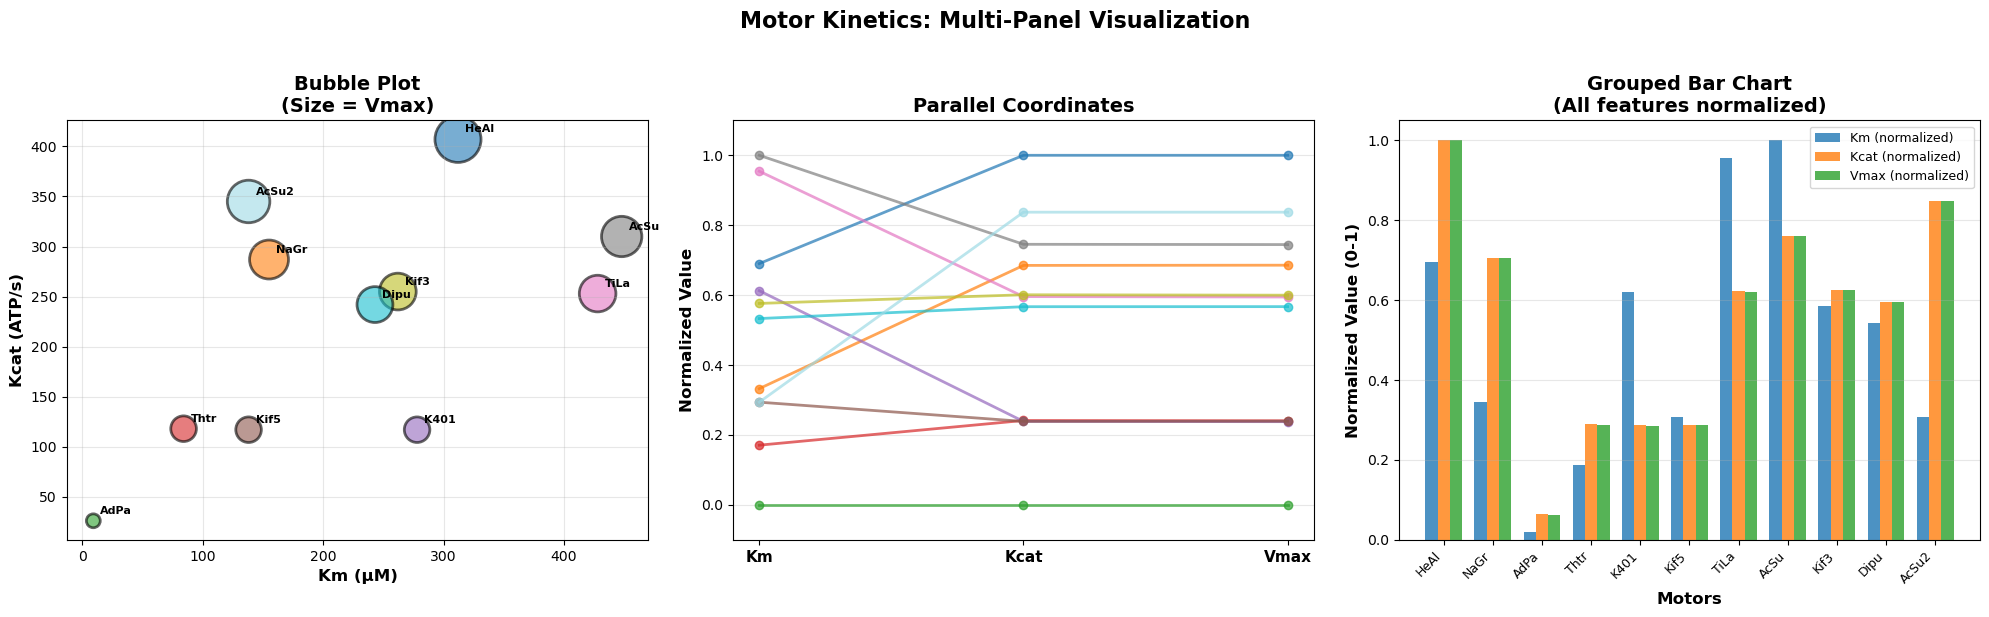

Multi-panel visualization created!


In [7]:
# Option 5: Combined Multi-Panel View
# Show all three visualization types side by side
fig = plt.figure(figsize=(20, 6))

# Panel 1: Bubble Plot
ax1 = plt.subplot(1, 3, 1)
vmax_normalized = (vmax - vmax.min()) / (vmax.max() - vmax.min())
bubble_sizes = 100 + vmax_normalized * 1000
scatter = ax1.scatter(km, kcat, s=bubble_sizes, alpha=0.6, 
                     c=range(len(motors)), cmap='tab20', 
                     edgecolors='black', linewidth=2)
for i, motor in enumerate(motors):
    ax1.annotate(motor, (km[i], kcat[i]), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold')
ax1.set_xlabel('Km (µM)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Kcat (ATP/s)', fontsize=12, fontweight='bold')
ax1.set_title('Bubble Plot\n(Size = Vmax)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Panel 2: Parallel Coordinates
ax2 = plt.subplot(1, 3, 2)
km_norm = (km - km.min()) / (km.max() - km.min())
kcat_norm = (kcat - kcat.min()) / (kcat.max() - kcat.min())
vmax_norm = (vmax - vmax.min()) / (vmax.max() - vmax.min())
x_positions = [0, 1, 2]
feature_names = ['Km', 'Kcat', 'Vmax']
colors = plt.cm.tab20(np.linspace(0, 1, len(motors)))
for i, motor in enumerate(motors):
    values = [km_norm[i], kcat_norm[i], vmax_norm[i]]
    ax2.plot(x_positions, values, marker='o', linewidth=2, 
            markersize=6, color=colors[i], alpha=0.7)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(feature_names, fontsize=11, fontweight='bold')
ax2.set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
ax2.set_title('Parallel Coordinates', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(-0.1, 1.1)

# Panel 3: Scaled Bar Chart (stacked or grouped)
ax3 = plt.subplot(1, 3, 3)
x_pos = np.arange(len(motors))
width = 0.25
# Normalize for better visualization
km_scaled = km / km.max()
kcat_scaled = kcat / kcat.max()
vmax_scaled = vmax / vmax.max()

bars1 = ax3.bar(x_pos - width, km_scaled, width, label='Km (normalized)', 
                alpha=0.8, color='#1f77b4')
bars2 = ax3.bar(x_pos, kcat_scaled, width, label='Kcat (normalized)', 
                alpha=0.8, color='#ff7f0e')
bars3 = ax3.bar(x_pos + width, vmax_scaled, width, label='Vmax (normalized)', 
                alpha=0.8, color='#2ca02c')

ax3.set_xlabel('Motors', fontsize=12, fontweight='bold')
ax3.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
ax3.set_title('Grouped Bar Chart\n(All features normalized)', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(motors, rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('Motor Kinetics: Multi-Panel Visualization', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Multi-panel visualization created!")


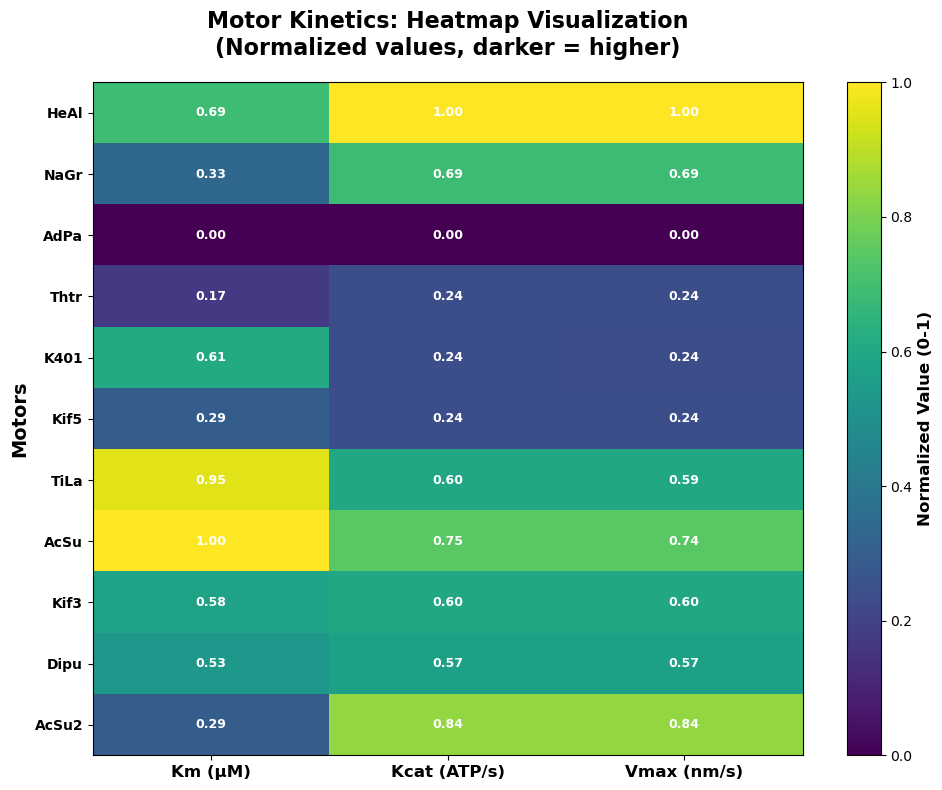

Heatmap visualization created!


In [8]:
# Option 6: Heatmap-style visualization
# Show all three features as a heatmap with motors as rows
fig, ax = plt.subplots(figsize=(10, 8))

# Normalize each feature to 0-1 scale
km_norm = (km - km.min()) / (km.max() - km.min())
kcat_norm = (kcat - kcat.min()) / (kcat.max() - kcat.min())
vmax_norm = (vmax - vmax.min()) / (vmax.max() - vmax.min())

# Create matrix: rows = motors, columns = features
heatmap_data = np.array([km_norm, kcat_norm, vmax_norm]).T

# Create heatmap
im = ax.imshow(heatmap_data, cmap='viridis', aspect='auto', vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)'], fontsize=12, fontweight='bold')
ax.set_yticks(range(len(motors)))
ax.set_yticklabels(motors, fontsize=10, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Value (0-1)', fontsize=12, fontweight='bold')

# Add text annotations with actual values
for i in range(len(motors)):
    for j in range(3):
        text = ax.text(j, i, f'{heatmap_data[i, j]:.2f}',
                      ha="center", va="center", color="white", fontweight='bold', fontsize=9)

ax.set_title('Motor Kinetics: Heatmap Visualization\n(Normalized values, darker = higher)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Motors', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Heatmap visualization created!")


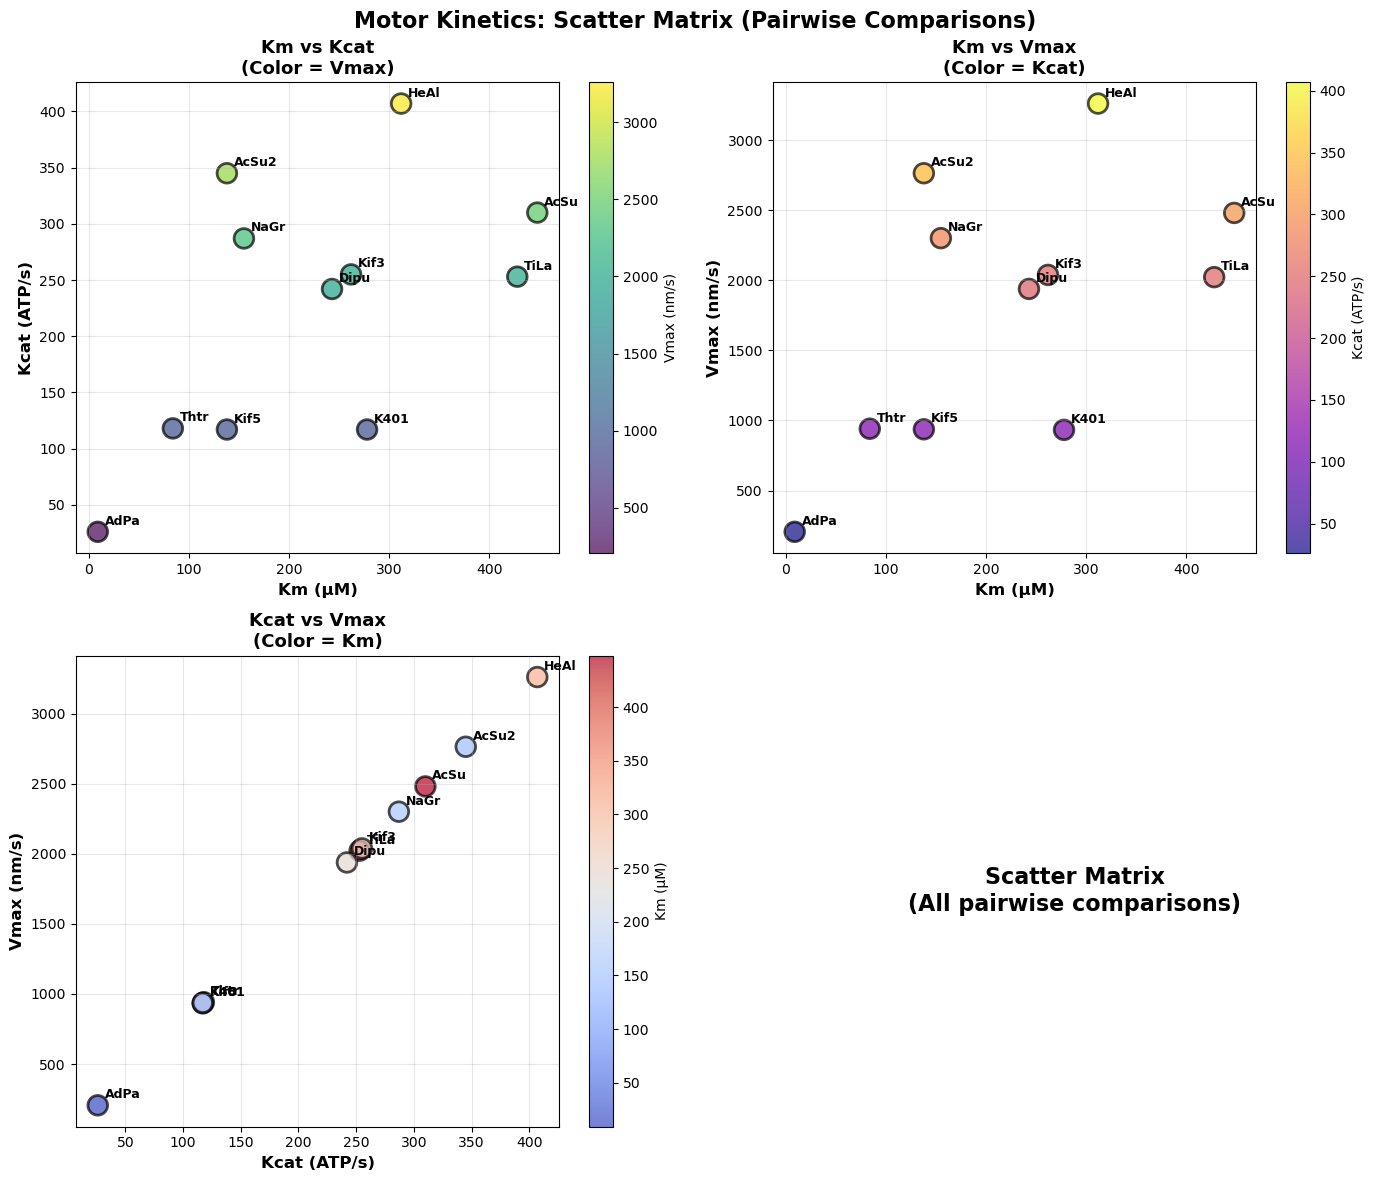

Scatter matrix created!


In [9]:
# Option 7: Scatter Matrix (Pairwise comparisons)
# Show all pairwise relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Km vs Kcat (with Vmax as color)
scatter1 = axes[0, 0].scatter(km, kcat, c=vmax, s=200, cmap='viridis', 
                              alpha=0.7, edgecolors='black', linewidth=2)
for i, motor in enumerate(motors):
    axes[0, 0].annotate(motor, (km[i], kcat[i]), 
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, fontweight='bold')
axes[0, 0].set_xlabel('Km (µM)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Kcat (ATP/s)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Km vs Kcat\n(Color = Vmax)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Vmax (nm/s)')

# Plot 2: Km vs Vmax (with Kcat as color)
scatter2 = axes[0, 1].scatter(km, vmax, c=kcat, s=200, cmap='plasma', 
                              alpha=0.7, edgecolors='black', linewidth=2)
for i, motor in enumerate(motors):
    axes[0, 1].annotate(motor, (km[i], vmax[i]), 
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, fontweight='bold')
axes[0, 1].set_xlabel('Km (µM)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Vmax (nm/s)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Km vs Vmax\n(Color = Kcat)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='Kcat (ATP/s)')

# Plot 3: Kcat vs Vmax (with Km as color)
scatter3 = axes[1, 0].scatter(kcat, vmax, c=km, s=200, cmap='coolwarm', 
                              alpha=0.7, edgecolors='black', linewidth=2)
for i, motor in enumerate(motors):
    axes[1, 0].annotate(motor, (kcat[i], vmax[i]), 
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, fontweight='bold')
axes[1, 0].set_xlabel('Kcat (ATP/s)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Vmax (nm/s)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Kcat vs Vmax\n(Color = Km)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Km (µM)')

# Plot 4: Combined view - all three as bar chart with error bars
axes[1, 1].axis('off')
# Create a summary text or remove this subplot
axes[1, 1].text(0.5, 0.5, 'Scatter Matrix\n(All pairwise comparisons)', 
                ha='center', va='center', fontsize=16, fontweight='bold',
                transform=axes[1, 1].transAxes)

plt.suptitle('Motor Kinetics: Scatter Matrix (Pairwise Comparisons)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Scatter matrix created!")


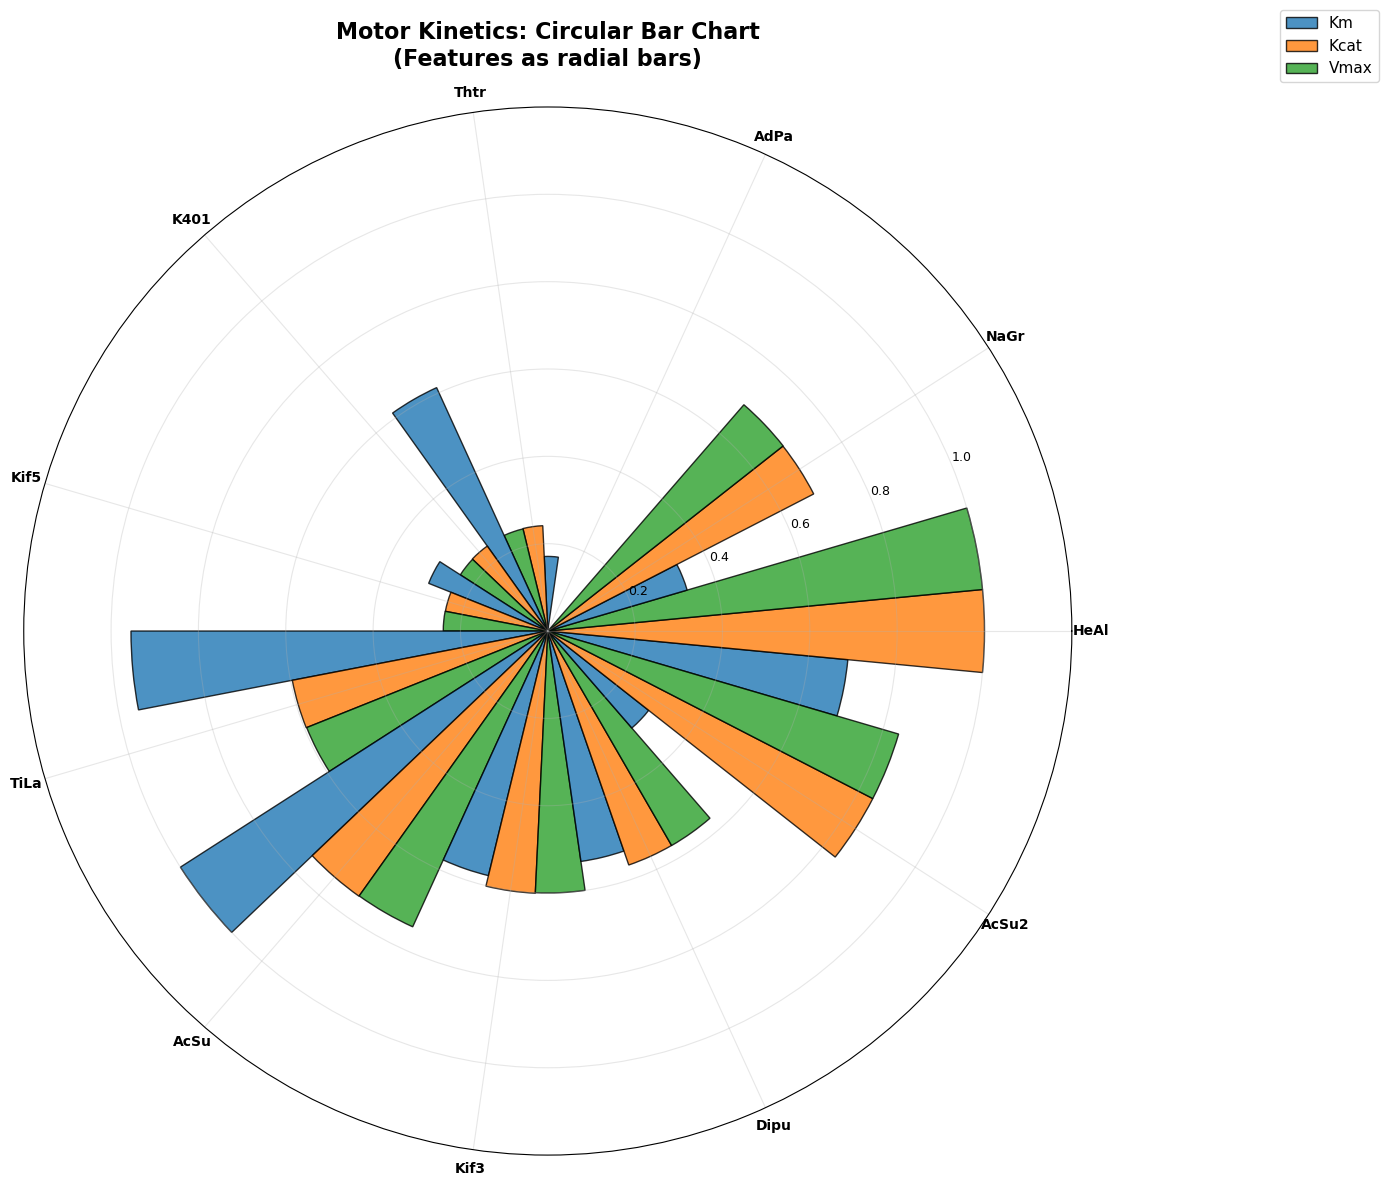

Circular bar chart created!


In [10]:
# Option 8: Circular/Radial Bar Chart
# Arrange motors in a circle, show features as bars extending outward
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(projection='polar'))

# Normalize features
km_norm = (km - km.min()) / (km.max() - km.min())
kcat_norm = (kcat - kcat.min()) / (kcat.max() - kcat.min())
vmax_norm = (vmax - vmax.min()) / (vmax.max() - vmax.min())

# Create angles for each motor (evenly spaced around circle)
angles = np.linspace(0, 2 * np.pi, len(motors), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

# Plot bars for each feature
width = 2 * np.pi / len(motors) / 3  # Divide by 3 to fit 3 bars per motor

for i, motor in enumerate(motors):
    angle = angles[i]
    # Plot three bars for each motor (slightly offset)
    ax.bar(angle - width, km_norm[i], width=width, label='Km' if i == 0 else '', 
           color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=1)
    ax.bar(angle, kcat_norm[i], width=width, label='Kcat' if i == 0 else '', 
           color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=1)
    ax.bar(angle + width, vmax_norm[i], width=width, label='Vmax' if i == 0 else '', 
           color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1)

# Customize
ax.set_xticks(angles[:-1])
ax.set_xticklabels(motors, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.2)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('Motor Kinetics: Circular Bar Chart\n(Features as radial bars)', 
             fontsize=16, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()

print("Circular bar chart created!")


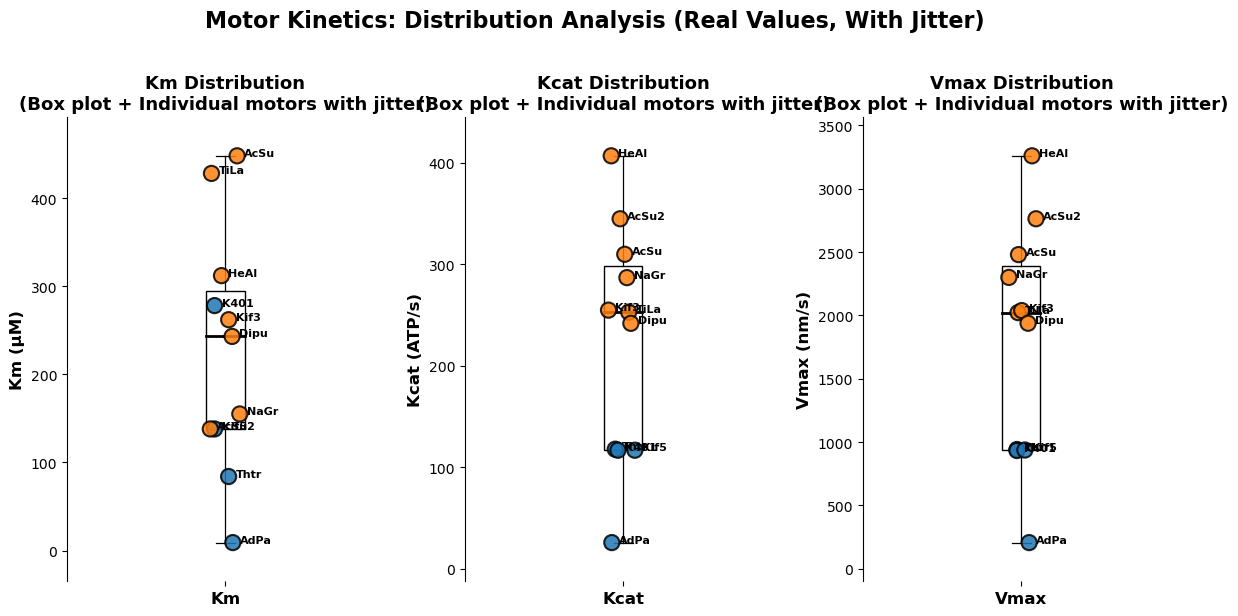

Distribution plot created with real values and jitter! (SVG saved)


In [41]:
# Option 9: Thin Box Plot Combination (with REAL values, frame markers colored, minimal box color, WITH JITTER)
from matplotlib import colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(12, 6))  # Make figure not as wide

# Use REAL values (not normalized)
features_data = [km, kcat, vmax]
feature_names_short = ['Km', 'Kcat', 'Vmax']
feature_units = ['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']

# Default matplotlib tab colors
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
blue = '#1f77b4'
orange = '#ff7f0e'
special_motors = ['Thtr', 'Kif5', 'AdPa', 'K401']

for idx, (data, name, unit) in enumerate(zip(features_data, feature_names_short, feature_units)):
    ax = axes[idx]
    
    # Make boxes very thin, no box fill color, thinner whitespace around plots
    bp = ax.boxplot(
        [data], vert=True, patch_artist=True, widths=0.12,
        boxprops=dict(facecolor='none', alpha=1, linewidth=1),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='black', linewidth=0.9),
        capprops=dict(color='black', linewidth=0.9)
    )
    
    # Add individual points with motor labels, blue for some, orange for others
    # --- ADD JITTER ---
    np.random.seed(42 + idx)  # For reproducible jitter, different per plot
    jitter_strength = 0.05  # Control the amount of jitter around the "1" x-position
    y_pos = 1 + np.random.uniform(-jitter_strength, jitter_strength, size=len(data))
    # --- END JITTER ---
    
    motor_colors = [blue if m in special_motors else orange for m in motors]
    scatter = ax.scatter(
        y_pos, data, s=120, c=motor_colors, alpha=0.85, 
        edgecolors='black', linewidth=1.5, zorder=3
    )
    
    # Add motor labels
    for i, motor in enumerate(motors):
        ax.annotate(
            motor, (y_pos[i], data[i]), 
            xytext=(5, 0), textcoords='offset points',
            fontsize=8, fontweight='bold', rotation=0
        )
     
    # Set y-axis label with proper units
    ax.set_ylabel(unit, fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Distribution\n(Box plot + Individual motors with jitter)', 
                fontsize=13, fontweight='bold')
    ax.set_xticks([1])
    ax.set_xticklabels([name], fontsize=12, fontweight='bold')
    
    # Set y-axis limits based on actual data range with some padding
    data_min = data.min()
    data_max = data.max()
    data_range = data_max - data_min
    ax.set_ylim(data_min - 0.1 * data_range, data_max + 0.1 * data_range)
    
    # Remove background/grid lines
    ax.grid(False)
    ax.set_axisbelow(False)

    # Remove top, right, and bottom spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.suptitle('Motor Kinetics: Distribution Analysis (Real Values, With Jitter)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# --- SAVE AS SVG ---
plt.savefig("../../../../Downloads/motor_kinetics_distribution_real_values_jitter.svg", format="svg")
plt.show()

print("Distribution plot created with real values and jitter! (SVG saved)")


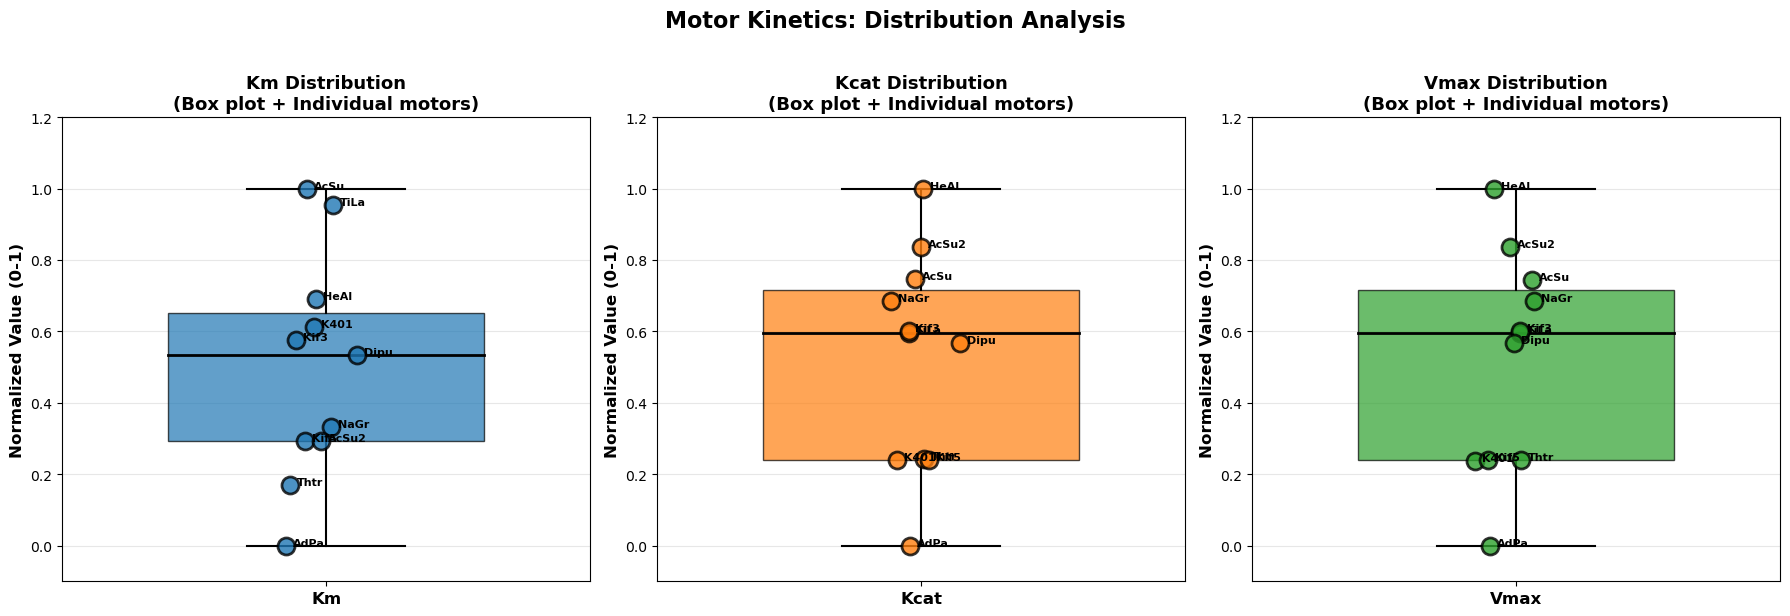

Distribution plot created!


In [28]:
# Option 9: Violin/Box Plot Combination
# Show distribution and individual values
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Normalize for comparison
km_norm = (km - km.min()) / (km.max() - km.min())
kcat_norm = (kcat - kcat.min()) / (kcat.max() - kcat.min())
vmax_norm = (vmax - vmax.min()) / (vmax.max() - vmax.min())

features_data = [km_norm, kcat_norm, vmax_norm]
feature_names_short = ['Km', 'Kcat', 'Vmax']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, (data, name, color) in enumerate(zip(features_data, feature_names_short, colors)):
    ax = axes[idx]
    
    # Create box plot
    bp = ax.boxplot([data], vert=True, patch_artist=True, widths=0.6,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(color='black', linewidth=1.5),
                    capprops=dict(color='black', linewidth=1.5))
    
    # Add individual points with motor labels
    y_pos = np.random.normal(1, 0.04, size=len(data))  # Jitter for visibility
    scatter = ax.scatter(y_pos, data, s=150, c=color, alpha=0.8, 
                        edgecolors='black', linewidth=2, zorder=3)
    
    # Add motor labels
    for i, motor in enumerate(motors):
        ax.annotate(motor, (y_pos[i], data[i]), 
                   xytext=(5, 0), textcoords='offset points',
                   fontsize=8, fontweight='bold', rotation=0)
    
    ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Distribution\n(Box plot + Individual motors)', 
                fontsize=13, fontweight='bold')
    ax.set_xticks([1])
    ax.set_xticklabels([name], fontsize=12, fontweight='bold')
    ax.set_ylim(-0.1, 1.2)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Motor Kinetics: Distribution Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Distribution plot created!")


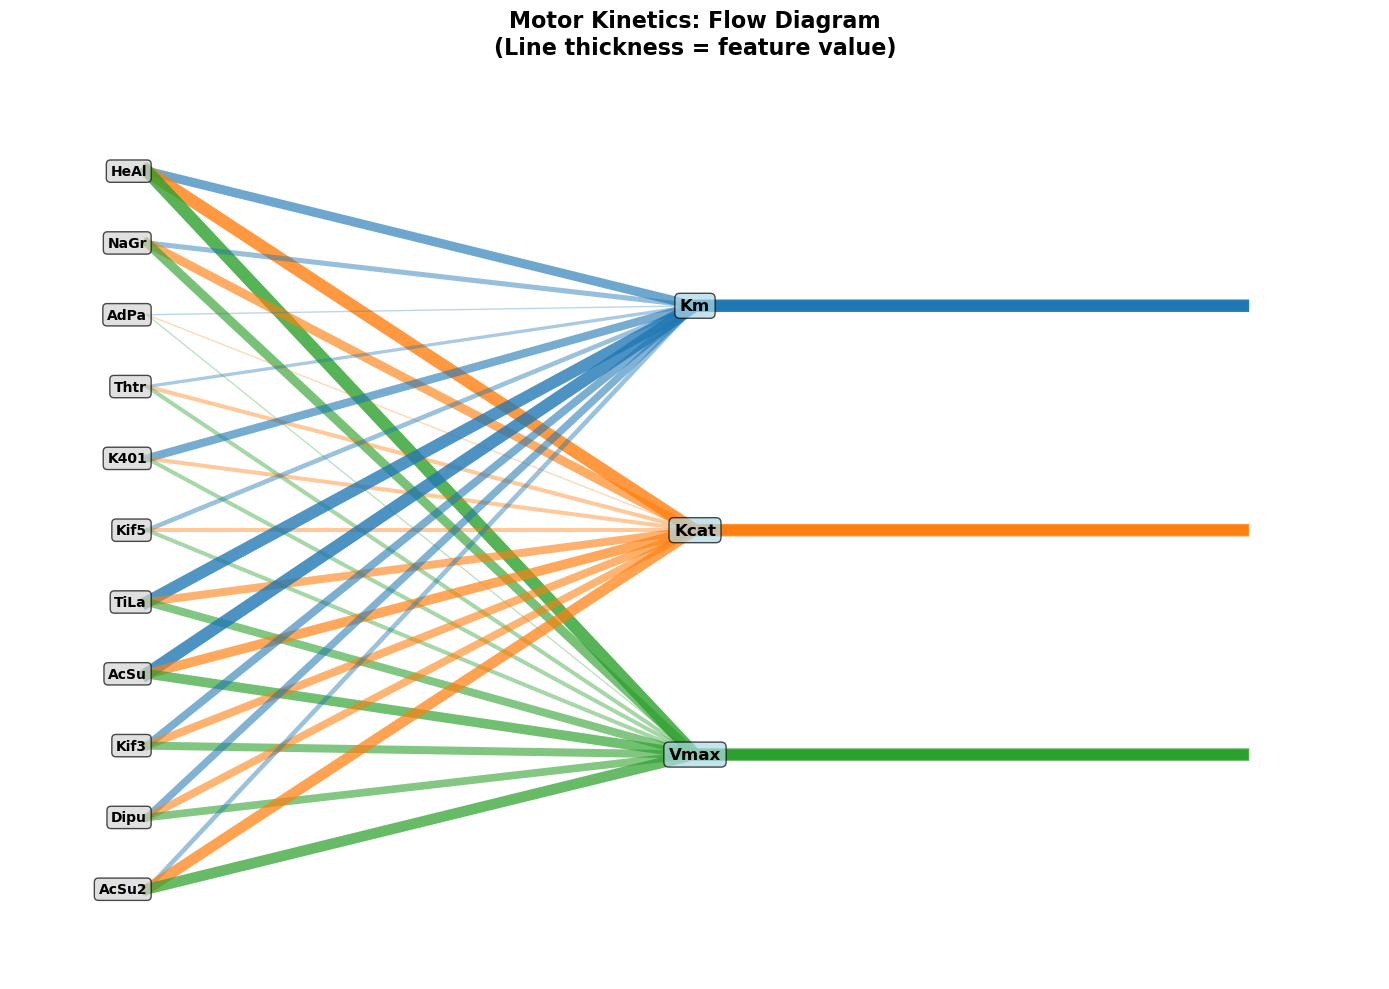

Flow diagram created!


In [12]:
# Option 10: Sankey-style Flow Diagram (Creative!)
# Show how motors relate to each feature
fig, ax = plt.subplots(figsize=(14, 10))

# Create three columns: Motors, Features (middle), and Feature values (right)
motor_x = 0.1
feature_x = 0.5
value_x = 0.9

# Y positions for motors (evenly spaced)
motor_y_positions = np.linspace(0.9, 0.1, len(motors))
feature_y_positions = [0.75, 0.5, 0.25]  # Three features
feature_names_plot = ['Km', 'Kcat', 'Vmax']

# Normalize for line thickness
km_norm = (km - km.min()) / (km.max() - km.min())
kcat_norm = (kcat - kcat.min()) / (kcat.max() - kcat.min())
vmax_norm = (vmax - vmax.min()) / (vmax.max() - vmax.min())

# Draw connections from motors to features (thickness = value)
for i, motor in enumerate(motors):
    motor_y = motor_y_positions[i]
    
    # Draw lines to each feature with thickness proportional to value
    for j, (feature_y, feature_name, value) in enumerate(zip(
        feature_y_positions, feature_names_plot, 
        [km_norm[i], kcat_norm[i], vmax_norm[i]])):
        
        linewidth = 1 + value * 8  # Scale line width
        alpha = 0.3 + value * 0.5  # Scale transparency
        
        # Choose color based on feature
        colors_map = {'Km': '#1f77b4', 'Kcat': '#ff7f0e', 'Vmax': '#2ca02c'}
        color = colors_map[feature_name]
        
        ax.plot([motor_x, feature_x, value_x], 
               [motor_y, feature_y, feature_y],
               linewidth=linewidth, alpha=alpha, color=color, zorder=1)

# Add motor labels
for i, motor in enumerate(motors):
    ax.text(motor_x, motor_y_positions[i], motor, 
           ha='right', va='center', fontsize=10, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

# Add feature labels
for feature_y, feature_name in zip(feature_y_positions, feature_names_plot):
    ax.text(feature_x, feature_y, feature_name, 
           ha='center', va='center', fontsize=12, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Motor Kinetics: Flow Diagram\n(Line thickness = feature value)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("Flow diagram created!")


In [13]:
# Check data structure and prepare for NMF analysis
print("Data shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()


Data shape: (11, 4)

Columns: ['Motor', 'Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']

First few rows:


,Motor,Km (µM),Kcat (ATP/s),Vmax (nm/s)
0,HeAl,312,407,3260
1,NaGr,155,287,2300
2,AdPa,9,26,206
3,Thtr,84,118,941
4,K401,278,117,933


In [14]:
# Create feature matrix for NMF analysis
print("Creating feature matrix for NMF analysis...")
print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Identify feature columns (exclude identifier columns like 'Motor')
identifier_cols = ['Motor', 'motor', 'protein', 'Protein', 'condition', 'Condition']
feature_cols = [col for col in df.columns if col not in identifier_cols]

print(f"\nFeature columns to use: {feature_cols}")

if len(feature_cols) == 0:
    raise ValueError("No feature columns found! Please check your data structure.")

# Get motor names (identifiers)
if 'Motor' in df.columns:
    motor_names = df['Motor'].values
elif 'motor' in df.columns:
    motor_names = df['motor'].values
elif 'protein' in df.columns:
    motor_names = df['protein'].values
elif 'Protein' in df.columns:
    motor_names = df['Protein'].values
else:
    motor_names = [f"Motor_{i+1}" for i in range(len(df))]

print(f"\nNumber of motors: {len(motor_names)}")
print(f"Motors: {motor_names.tolist()}")

# Create feature matrix: rows = motors, columns = features
feature_matrix = df[feature_cols].values

# Handle missing values
print(f"\nChecking for missing values...")
missing_count = np.isnan(feature_matrix).sum()
print(f"Total missing values: {missing_count}")

if missing_count > 0:
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    feature_matrix = imputer.fit_transform(feature_matrix)
    print("Imputed missing values using mean strategy")

# Ensure non-negative values (NMF requirement)
min_val = feature_matrix.min()
if min_val < 0:
    print(f"\nAdjusting for non-negativity: minimum value is {min_val:.3f}")
    feature_matrix = feature_matrix - min_val
    print(f"Added {abs(min_val):.3f} to all values")

print(f"\nFeature matrix shape: {feature_matrix.shape}")
print(f"  Rows (motors): {feature_matrix.shape[0]}")
print(f"  Columns (features): {feature_matrix.shape[1]}")
print(f"  Value range: [{feature_matrix.min():.3f}, {feature_matrix.max():.3f}]")


Creating feature matrix for NMF analysis...
Data shape: (11, 4)
Columns: ['Motor', 'Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']

Feature columns to use: ['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']

Number of motors: 11
Motors: ['HeAl', 'NaGr', 'AdPa', 'Thtr', 'K401', 'Kif5', 'TiLa', 'AcSu', 'Kif3', 'Dipu', 'AcSu2']

Checking for missing values...
Total missing values: 0

Feature matrix shape: (11, 3)
  Rows (motors): 11
  Columns (features): 3
  Value range: [9.000, 3260.000]


In [15]:
# Apply Z-score standardization (optional)
APPLY_ZSCORE = True
from sklearn.preprocessing import StandardScaler

if APPLY_ZSCORE:
    print("\nApplying Z-score standardization...")
    scaler = StandardScaler()
    feature_matrix_scaled = scaler.fit_transform(feature_matrix)
    
    # Ensure non-negative values (NMF requirement)
    min_val_scaled = feature_matrix_scaled.min()
    if min_val_scaled < 0:
        feature_matrix_scaled = feature_matrix_scaled - min_val_scaled
        print(f"  Adjusted for non-negativity: added {abs(min_val_scaled):.3f}")
    
    multi_feature_matrix = feature_matrix_scaled
    print(f"  Scaled matrix range: [{multi_feature_matrix.min():.3f}, {multi_feature_matrix.max():.3f}]")
else:
    multi_feature_matrix = feature_matrix
    print("\nUsing raw feature values (no scaling)")

# Store metadata
feature_names = feature_cols
motor_names_list = motor_names.tolist()

print(f"\n✅ Feature matrix ready for NMF analysis!")
print(f"   Matrix shape: {multi_feature_matrix.shape}")
print(f"   Features: {feature_names}")



Applying Z-score standardization...
  Adjusted for non-negativity: added 1.798
  Scaled matrix range: [0.000, 3.483]

✅ Feature matrix ready for NMF analysis!
   Matrix shape: (11, 3)
   Features: ['Km (µM)', 'Kcat (ATP/s)', 'Vmax (nm/s)']


In [16]:
# NMF reconstruction error analysis
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, r2_score

print("Setting up NMF reconstruction error analysis...")

# Define range of components to test
max_components = min(10, min(multi_feature_matrix.shape))
n_components_range = range(1, max_components + 1, 1)
print(f"Testing NMF with {len(n_components_range)} different component numbers: {list(n_components_range)}")
print(f"Matrix dimensions: {multi_feature_matrix.shape[0]} motors × {multi_feature_matrix.shape[1]} features")

# Store reconstruction errors
reconstruction_errors = []
explained_variance_ratios = []

print("\nComputing reconstruction errors for different numbers of components...")
for n_components in n_components_range:
    print(f"Testing {n_components} components...")
    
    # Fit NMF
    nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)
    W = nmf.fit_transform(multi_feature_matrix)
    H = nmf.components_
    
    # Reconstruct the matrix
    reconstructed = W @ H
    
    # Calculate reconstruction error
    mse = mean_squared_error(multi_feature_matrix.flatten(), reconstructed.flatten())
    reconstruction_errors.append(mse)
    
    # Calculate R² score
    r2 = r2_score(multi_feature_matrix.flatten(), reconstructed.flatten())
    explained_variance_ratios.append(r2)
    
    print(f"  MSE: {mse:.2e}, R² Score: {r2:.3f}")

print("\nReconstruction error analysis complete!")


Setting up NMF reconstruction error analysis...
Testing NMF with 3 different component numbers: [1, 2, 3]
Matrix dimensions: 11 motors × 3 features

Computing reconstruction errors for different numbers of components...
Testing 1 components...
  MSE: 1.97e-01, R² Score: 0.803
Testing 2 components...
  MSE: 6.66e-05, R² Score: 1.000
Testing 3 components...
  MSE: 1.26e-04, R² Score: 1.000

Reconstruction error analysis complete!


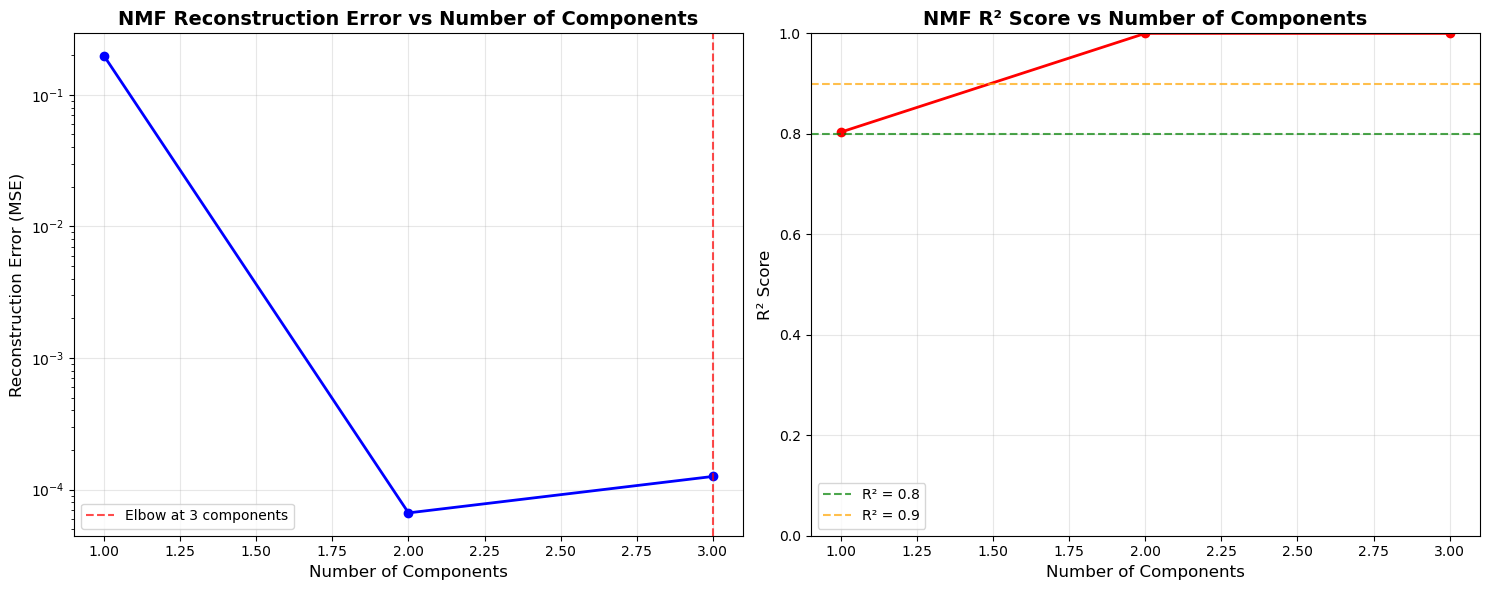


Optimal number of components (elbow method): 3
Using 3 components for NMF analysis


In [17]:
# Visualize reconstruction error and explained variance
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot reconstruction error (MSE)
ax1.plot(n_components_range, reconstruction_errors, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Reconstruction Error (MSE)', fontsize=12)
ax1.set_title('NMF Reconstruction Error vs Number of Components', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Add elbow detection
if len(reconstruction_errors) > 2:
    second_deriv = np.diff(reconstruction_errors, 2)
    if len(second_deriv) > 0:
        elbow_idx = np.argmax(second_deriv) + 2
        elbow_components = list(n_components_range)[elbow_idx]
        ax1.axvline(x=elbow_components, color='red', linestyle='--', alpha=0.7, 
                   label=f'Elbow at {elbow_components} components')
        ax1.legend()

# Plot R² score
ax2.plot(n_components_range, explained_variance_ratios, 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('NMF R² Score vs Number of Components', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)
ax2.axhline(y=0.8, color='green', linestyle='--', alpha=0.7, label='R² = 0.8')
ax2.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='R² = 0.9')
ax2.legend()

plt.tight_layout()
plt.show()

# Find optimal number of components
if len(reconstruction_errors) > 2:
    second_deriv = np.diff(reconstruction_errors, 2)
    if len(second_deriv) > 0:
        elbow_idx = np.argmax(second_deriv) + 2
        optimal_components = list(n_components_range)[elbow_idx]
        print(f"\nOptimal number of components (elbow method): {optimal_components}")
    else:
        optimal_components = min(3, max_components)
else:
    optimal_components = min(3, max_components)

print(f"Using {optimal_components} components for NMF analysis")


In [18]:
# Perform NMF with optimal number of components
print(f"Performing NMF with {optimal_components} components...")

# Fit NMF
nmf_optimal = NMF(n_components=optimal_components, random_state=42, max_iter=1000)
W_optimal = nmf_optimal.fit_transform(multi_feature_matrix)
H_optimal = nmf_optimal.components_

print(f"NMF factorization complete!")
print(f"W matrix shape (motors × components): {W_optimal.shape}")
print(f"H matrix shape (components × features): {H_optimal.shape}")

# Calculate final reconstruction error
reconstructed_optimal = W_optimal @ H_optimal
final_mse = mean_squared_error(multi_feature_matrix.flatten(), reconstructed_optimal.flatten())
final_r2 = r2_score(multi_feature_matrix.flatten(), reconstructed_optimal.flatten())

print(f"Final reconstruction MSE: {final_mse:.2e}")
print(f"Final R² Score: {final_r2:.3f}")

# Store results
nmf_results = {
    'n_components': optimal_components,
    'W': W_optimal,  # Motor weights (which components each motor uses)
    'H': H_optimal,  # Feature weights (which features each component represents)
    'reconstruction_error': final_mse,
    'r2_score': final_r2,
    'model': nmf_optimal,
    'motor_names': motor_names_list,
    'feature_names': feature_names
}

print(f"\nNMF analysis complete! Results stored in 'nmf_results' dictionary.")


Performing NMF with 3 components...
NMF factorization complete!
W matrix shape (motors × components): (11, 3)
H matrix shape (components × features): (3, 3)
Final reconstruction MSE: 1.26e-04
Final R² Score: 1.000

NMF analysis complete! Results stored in 'nmf_results' dictionary.


Visualizing NMF components (feature patterns)...


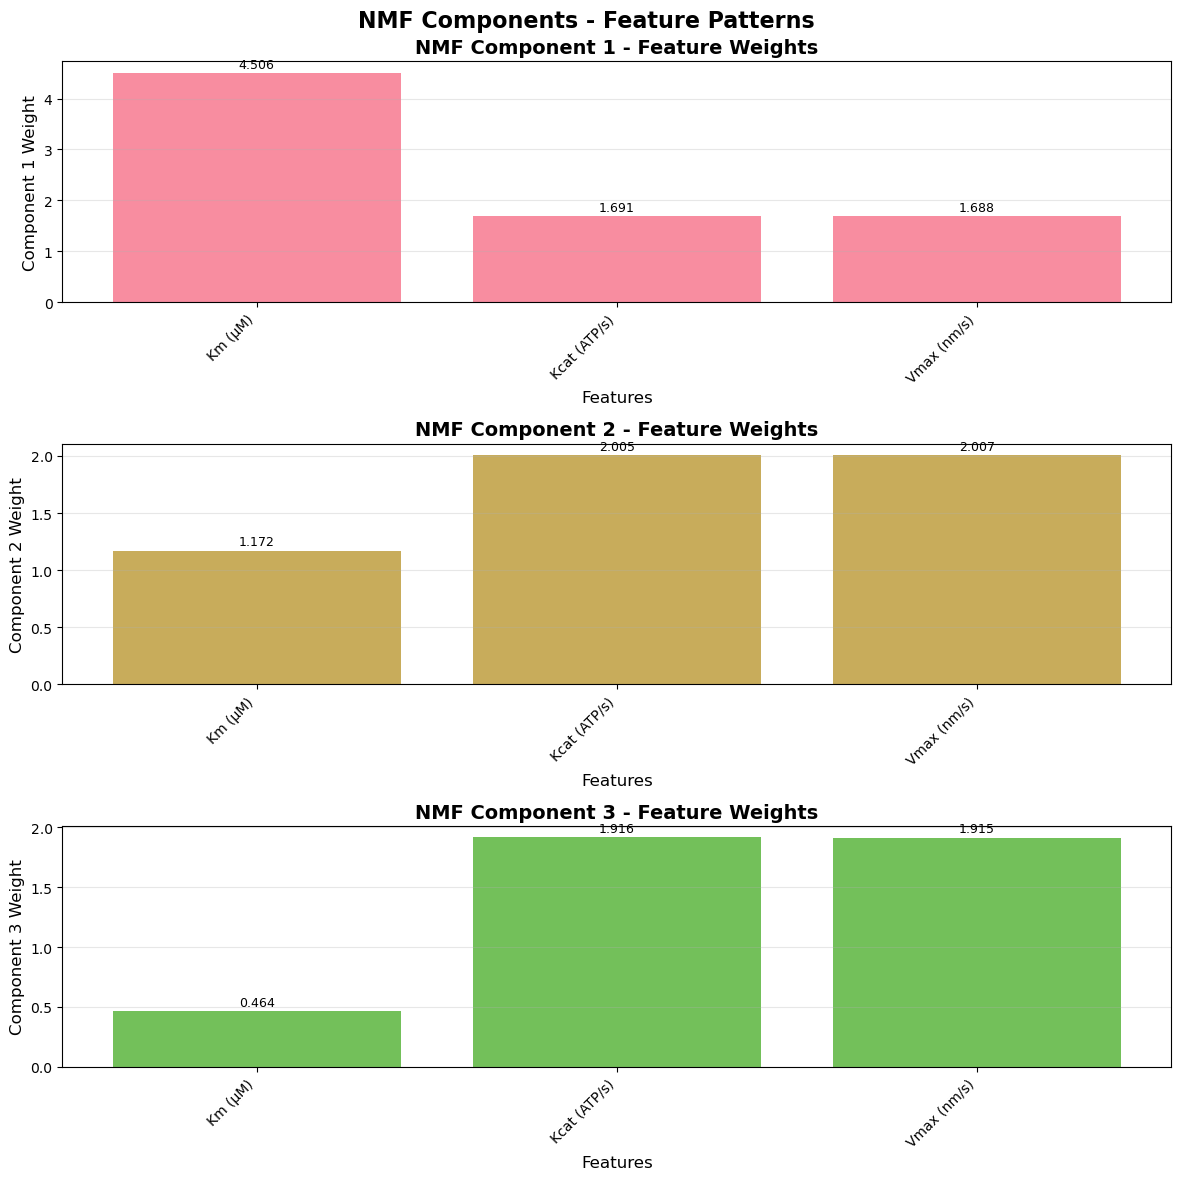

In [19]:
# Visualize NMF Components (H matrix - feature patterns)
print("Visualizing NMF components (feature patterns)...")

fig, axes = plt.subplots(optimal_components, 1, figsize=(12, 4*optimal_components))
if optimal_components == 1:
    axes = [axes]

for i in range(optimal_components):
    ax = axes[i]
    
    # Plot feature weights for this component
    feature_weights = nmf_results['H'][i, :]
    x_pos = np.arange(len(feature_names))
    
    bars = ax.bar(x_pos, feature_weights, alpha=0.8, color=f'C{i}')
    ax.set_title(f'NMF Component {i+1} - Feature Weights', fontsize=14, fontweight='bold')
    ax.set_xlabel('Features', fontsize=12)
    ax.set_ylabel(f'Component {i+1} Weight', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for j, (bar, weight) in enumerate(zip(bars, feature_weights)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(feature_weights),
                f'{weight:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('NMF Components - Feature Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


Visualizing NMF motor weights...


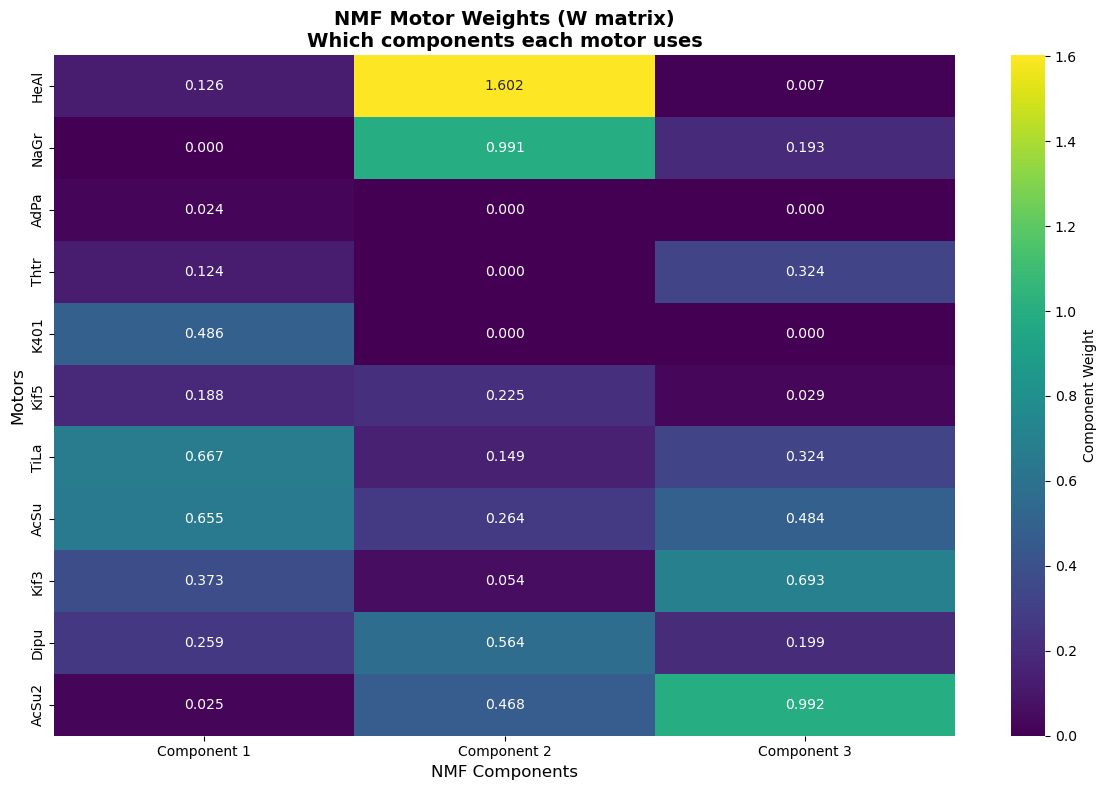

In [20]:
# Visualize NMF Motor Weights (W matrix - which components each motor uses)
print("Visualizing NMF motor weights...")

fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap of W matrix
import seaborn as sns
W_df = pd.DataFrame(nmf_results['W'], 
                    index=nmf_results['motor_names'],
                    columns=[f'Component {i+1}' for i in range(optimal_components)])

sns.heatmap(W_df, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'Component Weight'}, ax=ax)
ax.set_title('NMF Motor Weights (W matrix)\nWhich components each motor uses', fontsize=14, fontweight='bold')
ax.set_xlabel('NMF Components', fontsize=12)
ax.set_ylabel('Motors', fontsize=12)

plt.tight_layout()
plt.show()


In [21]:
# Identify dominant components for each motor and perform clustering
print("Identifying dominant NMF components and performing clustering...")

# Find the dominant component for each motor
dominant_components = np.argmax(nmf_results['W'], axis=1)
component_names = [f'Component {i+1}' for i in range(optimal_components)]

# Create summary dataframe
motor_summary = pd.DataFrame({
    'Motor': nmf_results['motor_names'],
    'Dominant_Component': [component_names[i] for i in dominant_components]
})

# Add component weights
for i in range(optimal_components):
    motor_summary[f'Component_{i+1}_Weight'] = nmf_results['W'][:, i]

print("\nMotor summary:")
print(motor_summary)

# Count component dominance
component_counts = pd.Series(dominant_components).value_counts().sort_index()
print(f"\nComponent dominance counts:")
for i, count in component_counts.items():
    print(f"  {component_names[i]}: {count} motors")

# Perform K-means clustering on NMF weights
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

W_matrix = nmf_results['W']  # (motors × components)
kmeans = KMeans(n_clusters=optimal_components, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(W_matrix)

# Calculate silhouette scores
silhouette_avg = silhouette_score(W_matrix, kmeans_labels)
silhouette_samples_vals = silhouette_samples(W_matrix, kmeans_labels)

print(f"\nK-means clustering complete!")
print(f"Overall Silhouette Score: {silhouette_avg:.3f}")

# Add cluster assignments to summary
motor_summary['Cluster'] = kmeans_labels + 1  # 1-indexed clusters

print("\nCluster assignments:")
print(motor_summary[['Motor', 'Cluster', 'Dominant_Component']])


Identifying dominant NMF components and performing clustering...

Motor summary:
    Motor Dominant_Component  Component_1_Weight  Component_2_Weight  \
0    HeAl        Component 2            0.125706            1.602094   
1    NaGr        Component 2            0.000000            0.991252   
2    AdPa        Component 1            0.024153            0.000000   
3    Thtr        Component 3            0.124285            0.000000   
4    K401        Component 1            0.485635            0.000033   
5    Kif5        Component 2            0.187593            0.224544   
6    TiLa        Component 1            0.667098            0.149276   
7    AcSu        Component 1            0.654581            0.263922   
8    Kif3        Component 3            0.373199            0.053533   
9    Dipu        Component 2            0.259302            0.563884   
10  AcSu2        Component 3            0.024884            0.467903   

    Component_3_Weight  
0             0.007369  
1   

Creating cluster visualization in PCA space...


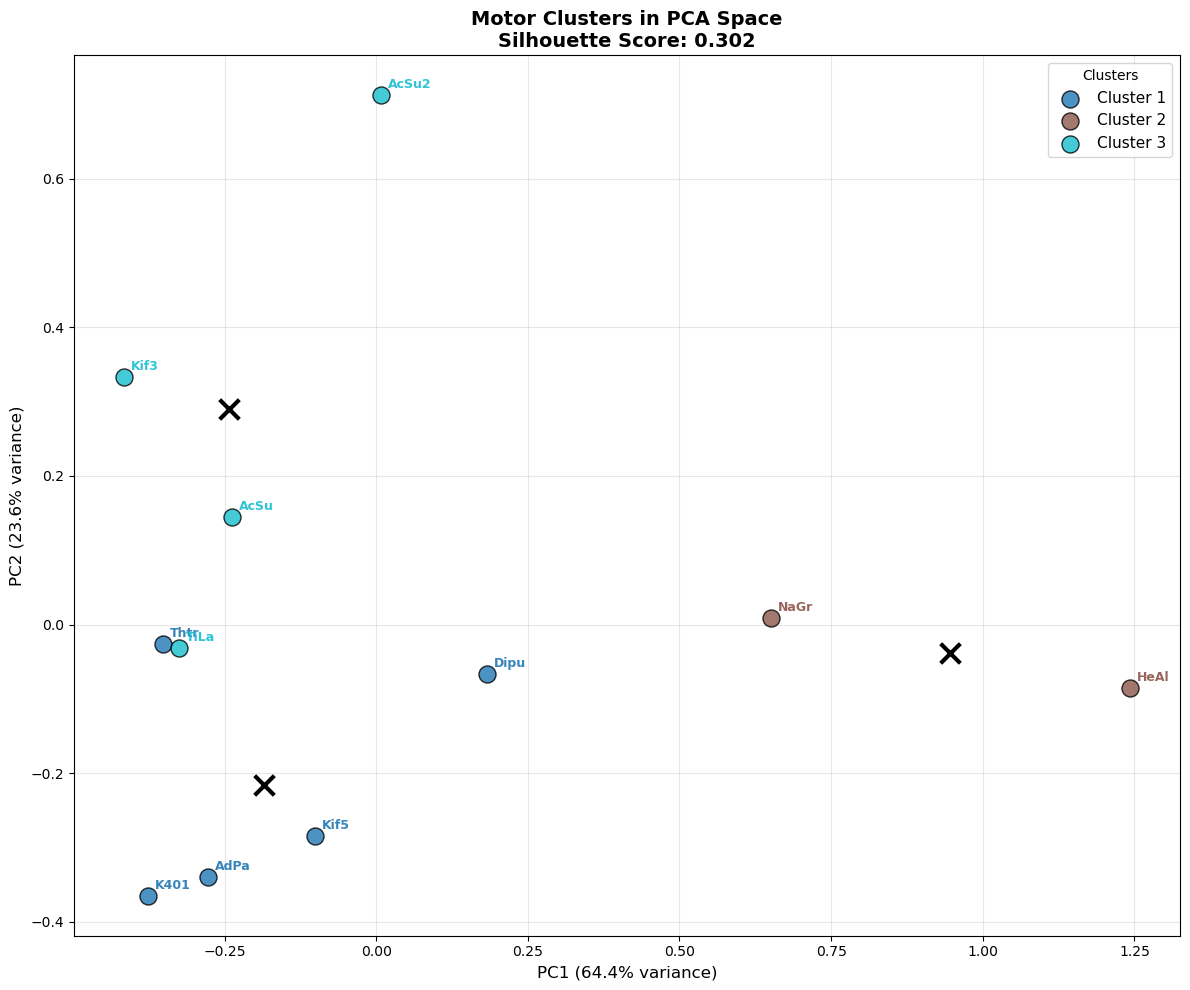

Cluster visualization complete!


In [22]:
# Visualize clusters in PCA space
from sklearn.decomposition import PCA

print("Creating cluster visualization in PCA space...")

# Create PCA projection
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(W_matrix)

# Define cluster colors
cluster_colors = plt.cm.tab10(np.linspace(0, 1, optimal_components))
cluster_names = [f'Cluster {i+1}' for i in range(optimal_components)]

# Create plot
fig, ax = plt.subplots(figsize=(12, 10))

for cluster_id in range(optimal_components):
    cluster_mask = kmeans_labels == cluster_id
    cluster_points = X_pca_2d[cluster_mask]
    color = cluster_colors[cluster_id]
    
    # Plot data points
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=[color], label=f'{cluster_names[cluster_id]}', 
               s=150, alpha=0.8, edgecolors='black', linewidth=1, zorder=2)
    
    # Add cluster centroid
    centroid_pc1 = cluster_points[:, 0].mean()
    centroid_pc2 = cluster_points[:, 1].mean()
    ax.scatter(centroid_pc1, centroid_pc2, marker='x', s=200, 
               color='black', linewidth=3, zorder=3)
    
    # Add labels
    for j, (x, y) in enumerate(zip(cluster_points[:, 0], cluster_points[:, 1])):
        motor_idx = np.where(cluster_mask)[0][j]
        motor_name = motor_summary.iloc[motor_idx]['Motor']
        ax.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                    fontsize=9, alpha=0.9, color=color, fontweight='bold', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'Motor Clusters in PCA Space\nSilhouette Score: {silhouette_avg:.3f}', 
             fontsize=14, fontweight='bold')
ax.legend(title='Clusters', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Cluster visualization complete!")


In [23]:
# Create final summary
print("\n" + "="*80)
print("FINAL MOTOR CLUSTER ANALYSIS")
print("="*80)

print(f"\nCLUSTER QUALITY ASSESSMENT:")
print(f"Overall Silhouette Score: {silhouette_avg:.3f}")
if silhouette_avg > 0.7:
    print("✅ EXCELLENT clustering - Strong, well-separated clusters")
elif silhouette_avg > 0.5:
    print("✅ GOOD clustering - Reasonable structure")
elif silhouette_avg > 0.25:
    print("⚠️  FAIR clustering - Weak but potentially meaningful structure")
else:
    print("❌ POOR clustering - No substantial structure")

# Summary by cluster
print("\nCluster Summary:")
for cluster_id in range(optimal_components):
    cluster_motors = motor_summary[motor_summary['Cluster'] == cluster_id + 1]
    cluster_silhouette_vals = silhouette_samples_vals[kmeans_labels == cluster_id]
    avg_silhouette = cluster_silhouette_vals.mean() if len(cluster_silhouette_vals) > 0 else 0
    
    print(f"\nCluster {cluster_id + 1} ({len(cluster_motors)} motors, Avg Silhouette: {avg_silhouette:.3f}):")
    print(f"  Motors: {', '.join(cluster_motors['Motor'].tolist())}")

print(f"\n" + "="*80)
print("MOTOR CLUSTER ASSIGNMENTS")
print("="*80)
print(motor_summary[['Motor', 'Cluster', 'Dominant_Component']].to_string(index=False))

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"✅ Successfully identified {optimal_components} motor clusters using NMF")
print(f"✅ Cluster Quality: Silhouette Score = {silhouette_avg:.3f}")
print("\n✅ Results available in:")
print("   • 'nmf_results' dictionary - NMF decomposition results")
print("   • 'motor_summary' dataframe - Cluster assignments and component weights")



FINAL MOTOR CLUSTER ANALYSIS

CLUSTER QUALITY ASSESSMENT:
Overall Silhouette Score: 0.302
⚠️  FAIR clustering - Weak but potentially meaningful structure

Cluster Summary:

Cluster 1 (5 motors, Avg Silhouette: 0.354):
  Motors: AdPa, Thtr, K401, Kif5, Dipu

Cluster 2 (2 motors, Avg Silhouette: 0.412):
  Motors: HeAl, NaGr

Cluster 3 (4 motors, Avg Silhouette: 0.182):
  Motors: TiLa, AcSu, Kif3, AcSu2

MOTOR CLUSTER ASSIGNMENTS
Motor  Cluster Dominant_Component
 HeAl        2        Component 2
 NaGr        2        Component 2
 AdPa        1        Component 1
 Thtr        1        Component 3
 K401        1        Component 1
 Kif5        1        Component 2
 TiLa        3        Component 1
 AcSu        3        Component 1
 Kif3        3        Component 3
 Dipu        1        Component 2
AcSu2        3        Component 3

ANALYSIS COMPLETE!
✅ Successfully identified 3 motor clusters using NMF
✅ Cluster Quality: Silhouette Score = 0.302

✅ Results available in:
   • 'nmf_results'

Creating PCA plot with KMeans clusters and silhouette visualization...


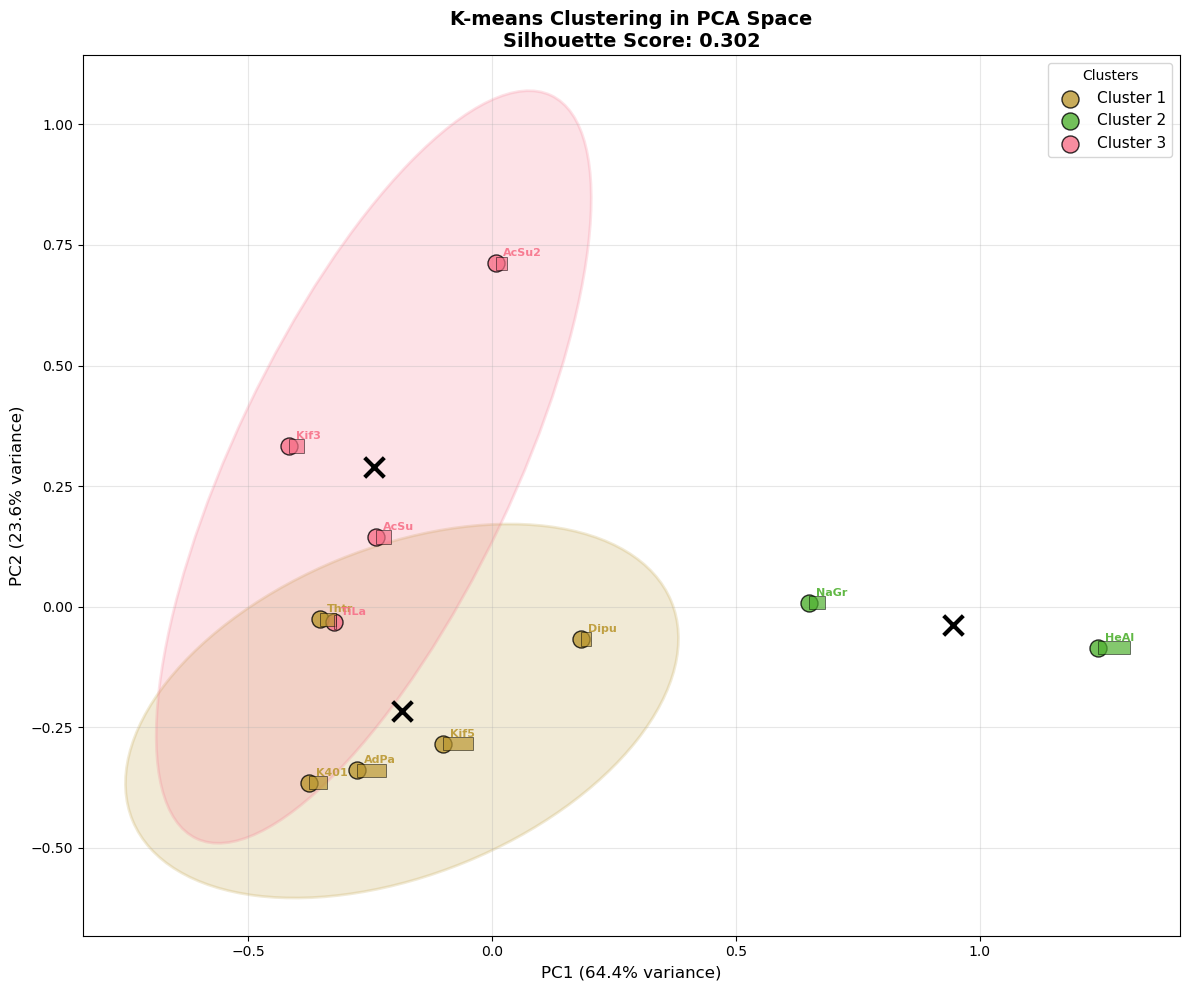

PCA plot with clusters, ellipses, and silhouette bars complete!


In [24]:
# PCA plot with KMeans clusters, ellipses, and silhouette bars overlaid (like tutorial)
print("Creating PCA plot with KMeans clusters and silhouette visualization...")

# Step 1: Use existing KMeans clustering (already done above)
# W_matrix is (motors × components)
# kmeans_labels already computed

# Step 2: Use existing silhouette scores (already computed above)
# silhouette_avg and silhouette_samples_vals already computed

# Step 3: Create PCA projection
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(W_matrix)

# Step 4: Create plot with clusters, ellipses, and silhouette bars
fig, ax = plt.subplots(figsize=(12, 10))

# Use the default matplotlib tab10 cycler: orange, green, blue for clusters 1/2/3
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# "tab:orange" is color index 1, "tab:green" is 2, "tab:blue" is 0 in tab10 palette
cluster_colors = [default_colors[1], default_colors[2], default_colors[0]]  # Orange, Green, Blue
cluster_names = [f'Cluster {i+1}' for i in range(optimal_components)]

# Plot clusters with ellipses (like tutorial)
for cluster_id in range(optimal_components):
    cluster_mask = kmeans_labels == cluster_id
    cluster_points = X_pca_2d[cluster_mask]
    color = cluster_colors[cluster_id]
    
    # Plot data points
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=color, label=f'{cluster_names[cluster_id]}', 
               s=150, alpha=0.8, edgecolors='black', linewidth=1, zorder=2)
    
    # Add cluster centroid
    centroid_pc1 = cluster_points[:, 0].mean()
    centroid_pc2 = cluster_points[:, 1].mean()
    ax.scatter(centroid_pc1, centroid_pc2, marker='x', s=200, 
               color='black', linewidth=3, zorder=3)
    
    # Draw cluster boundary (ellipse) using confidence ellipse
    if len(cluster_points) > 2:
        # Calculate ellipse parameters
        mean_x, mean_y = centroid_pc1, centroid_pc2
        cov_matrix = np.cov(cluster_points[:, 0], cluster_points[:, 1])
        
        # Create confidence ellipse (95% confidence)
        lambda_, v = np.linalg.eigh(cov_matrix)
        lambda_ = np.sqrt(lambda_)
        
        # Scale for 95% confidence
        scale = 2.447  # For 95% confidence (2 degrees of freedom)
        width = lambda_[0] * scale * 2
        height = lambda_[1] * scale * 2
        
        # Calculate angle
        angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
        
        # Draw ellipse
        ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle,
                          facecolor=color, alpha=0.2, 
                          edgecolor=color, linewidth=2, zorder=1)
        ax.add_patch(ellipse)

# Overlay silhouette bars on each point (like silhouette plot but positioned at each point)
bar_width_scale = 0.015  # Scale for bar width (relative to PCA space)
bar_length_scale = 0.12  # Scale factor for bar length

for idx in range(len(X_pca_2d)):
    x, y = X_pca_2d[idx, 0], X_pca_2d[idx, 1]
    cluster_id = kmeans_labels[idx]
    sil_score = silhouette_samples_vals[idx]
    color = cluster_colors[cluster_id]
    
    # Calculate bar dimensions (scale to PCA space)
    bar_length = sil_score * bar_length_scale
    # Get current axis limits to scale bar width appropriately
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0] if hasattr(ax, 'get_ylim') else 1.0
    bar_width = bar_width_scale * y_range
    
    # Draw horizontal silhouette bar (positive = right, negative = left)
    if bar_length >= 0:
        # Positive silhouette - bar to the right
        ax.barh(y, bar_length, height=bar_width, left=x, color=color, 
                alpha=0.7, edgecolor='black', linewidth=0.5, zorder=4)
    else:
        # Negative silhouette - bar to the left
        ax.barh(y, abs(bar_length), height=bar_width, left=x + bar_length, 
                color=color, alpha=0.7, edgecolor='black', linewidth=0.5, zorder=4)
    
    # Add motor labels
    motor_name = motor_summary.iloc[idx]['Motor']
    ax.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.9, color=color, fontweight='bold', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-means Clustering in PCA Space\nSilhouette Score: {silhouette_avg:.3f}', 
             fontsize=14, fontweight='bold')
ax.legend(title='Clusters', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("PCA plot with clusters, ellipses, and silhouette bars complete!")


Creating final motor cluster analysis...


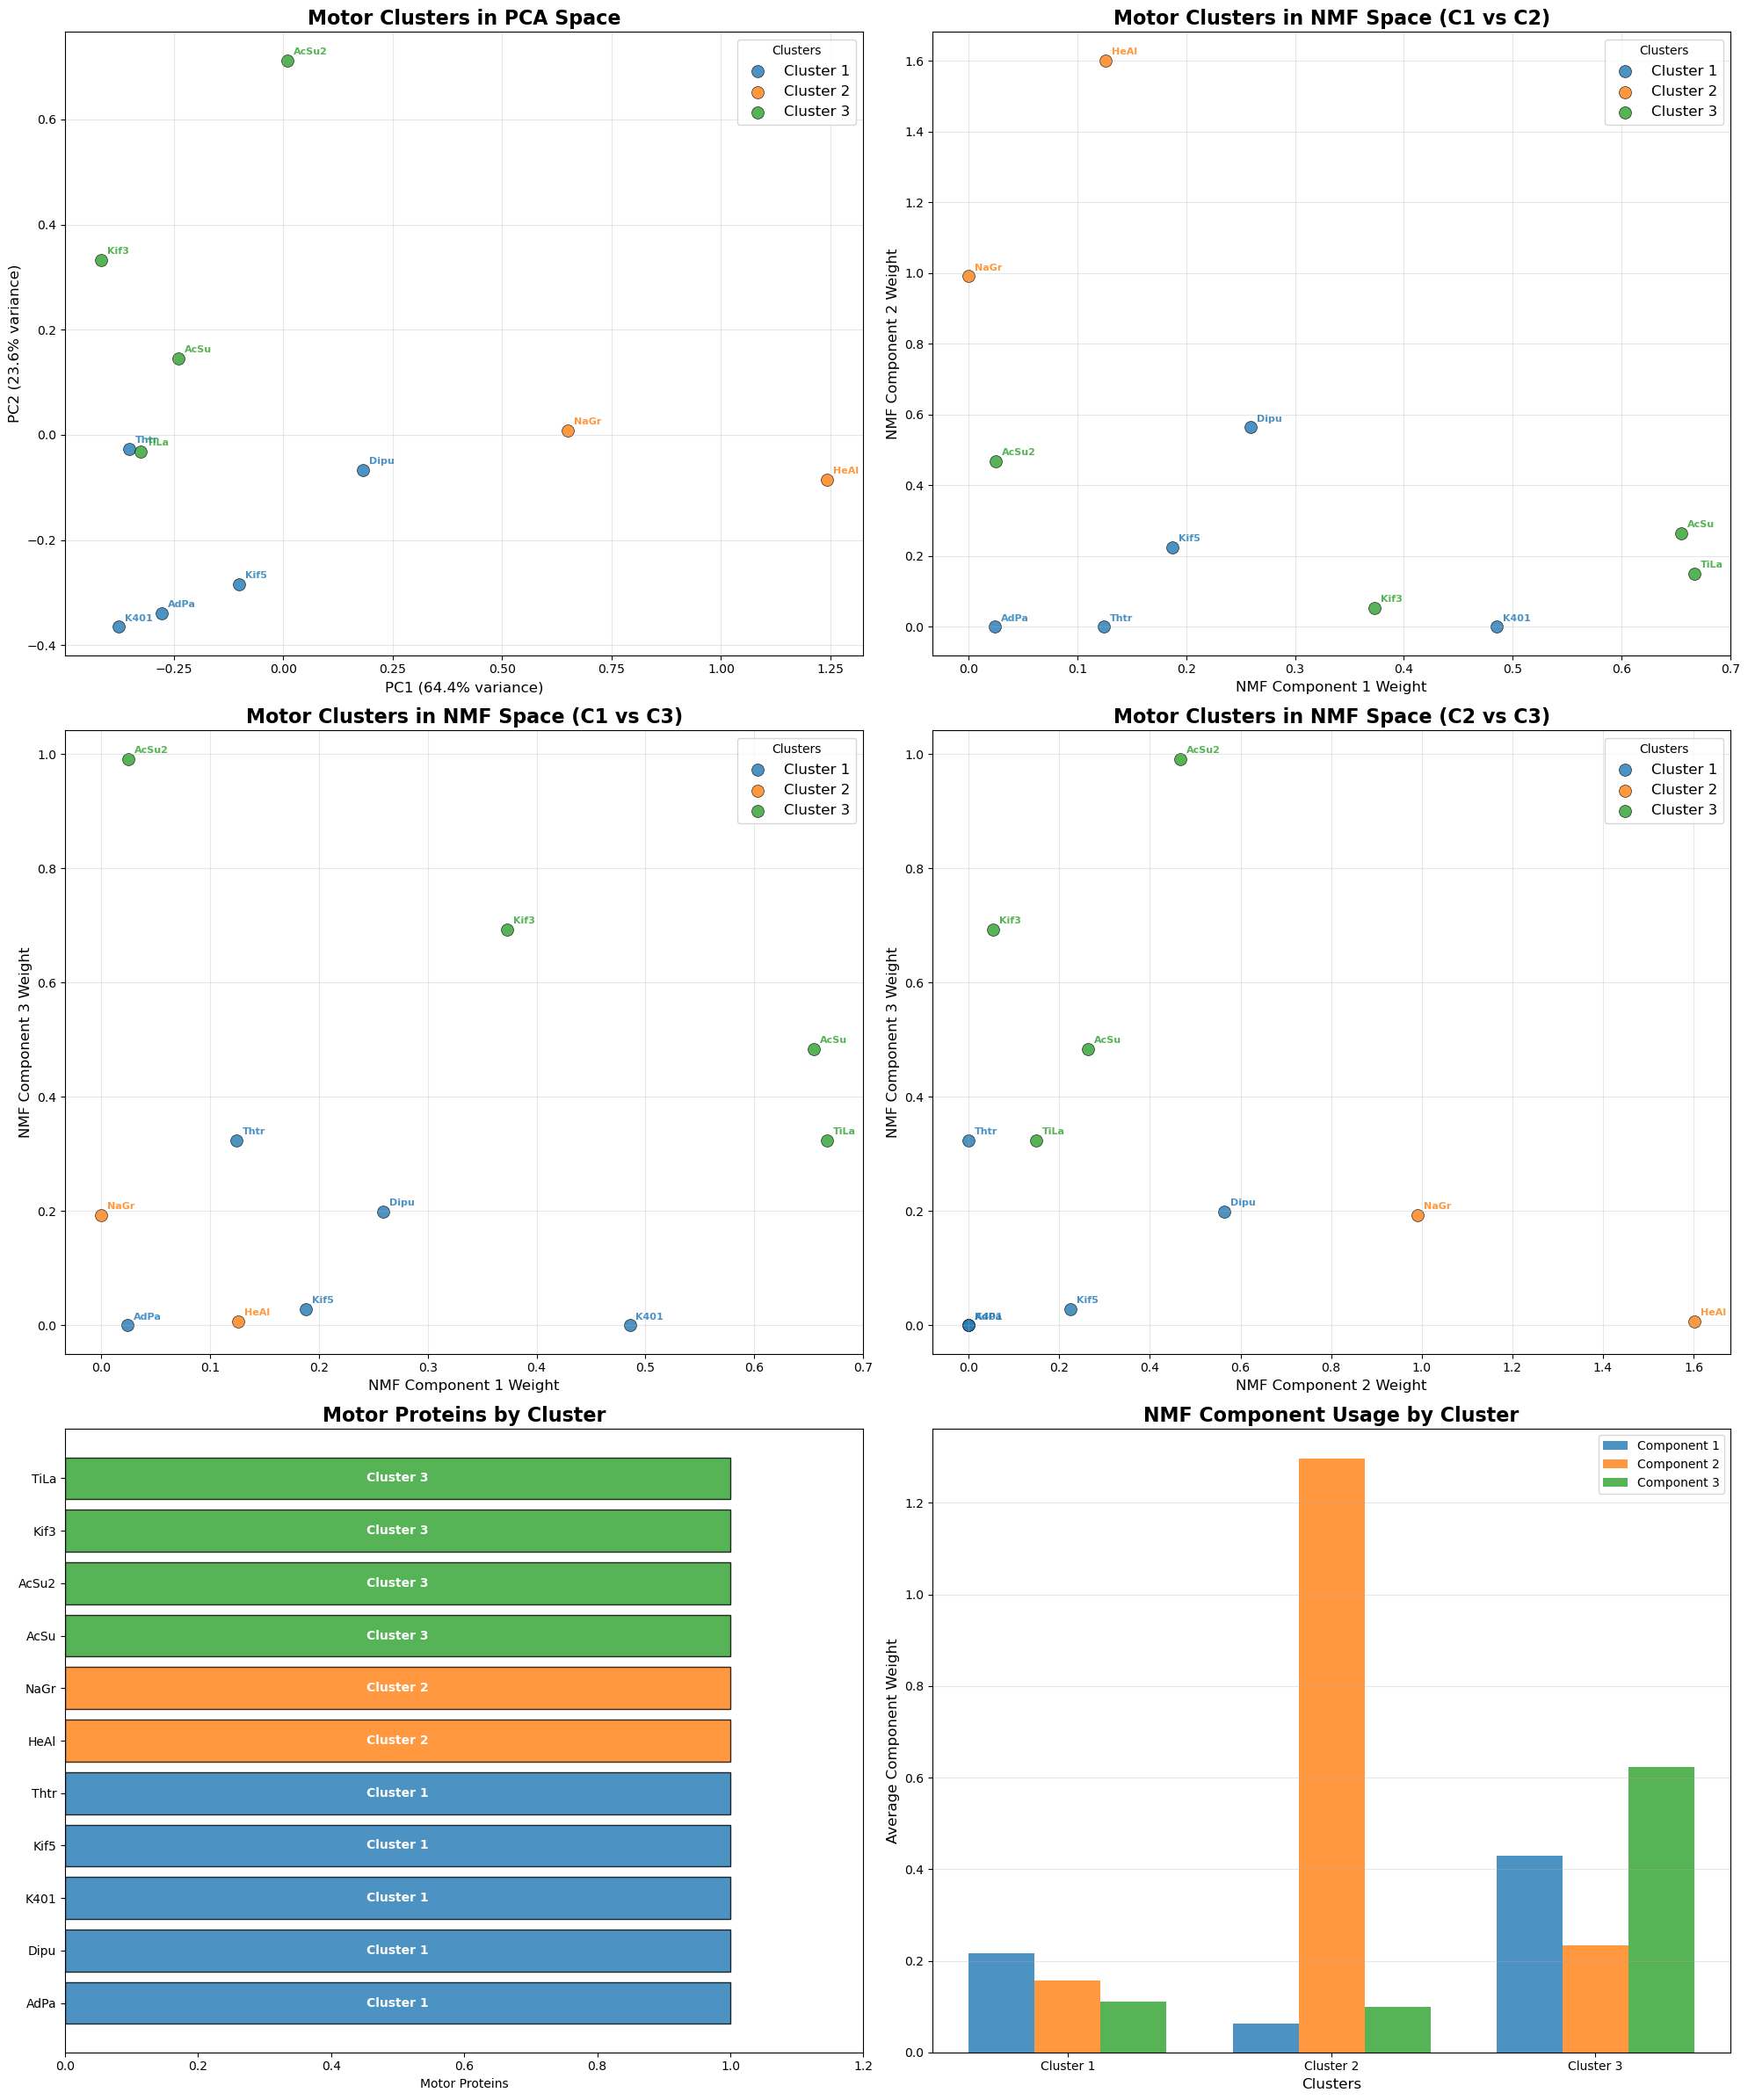

Final behavioral cluster analysis complete!


In [25]:
# Complete the analysis: Create final motor cluster visualization
print("Creating final motor cluster analysis...")

# Define consistent colors for the clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
cluster_names = [f'Cluster {i+1}' for i in range(optimal_components)]

# Create comprehensive visualization with both PCA and NMF projections
n_rows = 3
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 24))

# Plot 1: Motor clusters in PCA space
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(W_matrix)  # W_matrix is (motors × components)

ax1 = axes[0, 0]
for i in range(optimal_components):
    cluster_mask = kmeans_labels == i
    ax1.scatter(X_pca_2d[cluster_mask, 0], X_pca_2d[cluster_mask, 1], 
               c=cluster_colors[i], label=f'{cluster_names[i]}', 
               alpha=0.8, s=100, edgecolors='black', linewidth=0.5)
    
    # Add motor labels for each point
    for j, (x, y) in enumerate(zip(X_pca_2d[cluster_mask, 0], X_pca_2d[cluster_mask, 1])):
        motor_idx = np.where(cluster_mask)[0][j]
        motor_name = motor_summary.iloc[motor_idx]['Motor']
        ax1.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8, color=cluster_colors[i], fontweight='bold')

ax1.set_title('Motor Clusters in PCA Space', fontsize=16, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax1.legend(title='Clusters', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Motor clusters in NMF component space (Component 1 vs Component 2)
ax2 = axes[0, 1]
if optimal_components >= 2:
    for i in range(optimal_components):
        cluster_mask = kmeans_labels == i
        ax2.scatter(W_matrix[cluster_mask, 0], W_matrix[cluster_mask, 1], 
                   c=cluster_colors[i], label=f'{cluster_names[i]}', 
                   alpha=0.8, s=100, edgecolors='black', linewidth=0.5)
        
        # Add motor labels for each point
        for j, (x, y) in enumerate(zip(W_matrix[cluster_mask, 0], W_matrix[cluster_mask, 1])):
            motor_idx = np.where(cluster_mask)[0][j]
            motor_name = motor_summary.iloc[motor_idx]['Motor']
            ax2.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                        fontsize=8, alpha=0.8, color=cluster_colors[i], fontweight='bold')
    
    ax2.set_title('Motor Clusters in NMF Space (C1 vs C2)', fontsize=16, fontweight='bold')
    ax2.set_xlabel('NMF Component 1 Weight', fontsize=12)
    ax2.set_ylabel('NMF Component 2 Weight', fontsize=12)
    ax2.legend(title='Clusters', fontsize=12)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Need at least 2 components\nfor this visualization', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Motor Clusters in NMF Space (C1 vs C2)', fontsize=16, fontweight='bold')

# Plot 3: Motor clusters in NMF component space (Component 1 vs Component 3)
ax3 = axes[1, 0]
if optimal_components >= 3:
    for i in range(optimal_components):
        cluster_mask = kmeans_labels == i
        ax3.scatter(W_matrix[cluster_mask, 0], W_matrix[cluster_mask, 2], 
                   c=cluster_colors[i], label=f'{cluster_names[i]}', 
                   alpha=0.8, s=100, edgecolors='black', linewidth=0.5)
        
        # Add motor labels for each point
        for j, (x, y) in enumerate(zip(W_matrix[cluster_mask, 0], W_matrix[cluster_mask, 2])):
            motor_idx = np.where(cluster_mask)[0][j]
            motor_name = motor_summary.iloc[motor_idx]['Motor']
            ax3.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                        fontsize=8, alpha=0.8, color=cluster_colors[i], fontweight='bold')
    
    ax3.set_title('Motor Clusters in NMF Space (C1 vs C3)', fontsize=16, fontweight='bold')
    ax3.set_xlabel('NMF Component 1 Weight', fontsize=12)
    ax3.set_ylabel('NMF Component 3 Weight', fontsize=12)
    ax3.legend(title='Clusters', fontsize=12)
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Need at least 3 components\nfor this visualization', 
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Motor Clusters in NMF Space (C1 vs C3)', fontsize=16, fontweight='bold')

# Plot 4: Motor clusters in NMF component space (Component 2 vs Component 3)
ax4 = axes[1, 1]
if optimal_components >= 3:
    for i in range(optimal_components):
        cluster_mask = kmeans_labels == i
        ax4.scatter(W_matrix[cluster_mask, 1], W_matrix[cluster_mask, 2], 
                   c=cluster_colors[i], label=f'{cluster_names[i]}', 
                   alpha=0.8, s=100, edgecolors='black', linewidth=0.5)
        
        # Add motor labels for each point
        for j, (x, y) in enumerate(zip(W_matrix[cluster_mask, 1], W_matrix[cluster_mask, 2])):
            motor_idx = np.where(cluster_mask)[0][j]
            motor_name = motor_summary.iloc[motor_idx]['Motor']
            ax4.annotate(motor_name, (x, y), xytext=(5, 5), textcoords='offset points',
                        fontsize=8, alpha=0.8, color=cluster_colors[i], fontweight='bold')
    
    ax4.set_title('Motor Clusters in NMF Space (C2 vs C3)', fontsize=16, fontweight='bold')
    ax4.set_xlabel('NMF Component 2 Weight', fontsize=12)
    ax4.set_ylabel('NMF Component 3 Weight', fontsize=12)
    ax4.legend(title='Clusters', fontsize=12)
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Need at least 3 components\nfor this visualization', 
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('Motor Clusters in NMF Space (C2 vs C3)', fontsize=16, fontweight='bold')

# Plot 5: Motor proteins by cluster
ax5 = axes[2, 0]
# Sort motors by cluster
motor_summary_sorted = motor_summary.sort_values(['Cluster', 'Motor'])

# Create horizontal bar plot
y_pos = np.arange(len(motor_summary_sorted))
colors = [cluster_colors[int(cluster) - 1] for cluster in motor_summary_sorted['Cluster']]

bars = ax5.barh(y_pos, [1]*len(motor_summary_sorted), color=colors, alpha=0.8, edgecolor='black')
ax5.set_yticks(y_pos)
ax5.set_yticklabels(motor_summary_sorted['Motor'])
ax5.set_xlabel('Motor Proteins')
ax5.set_title('Motor Proteins by Cluster', fontsize=16, fontweight='bold')
ax5.set_xlim(0, 1.2)

# Add cluster labels to bars
for i, (motor, cluster) in enumerate(motor_summary_sorted[['Motor', 'Cluster']].values):
    ax5.text(0.5, i, f'Cluster {int(cluster)}', ha='center', va='center', 
             fontweight='bold', color='white', fontsize=10)

# Plot 6: NMF component usage by cluster
ax6 = axes[2, 1]
# Calculate average component weights for each cluster
component_weight_cols = [f'Component_{i+1}_Weight' for i in range(optimal_components)]
cluster_components = motor_summary.groupby('Cluster')[component_weight_cols].mean()

x = np.arange(len(cluster_components))
width = 0.25 if optimal_components <= 3 else 0.8 / optimal_components

# Create bars for each component
for i in range(optimal_components):
    offset = (i - optimal_components/2 + 0.5) * width
    bars = ax6.bar(x + offset, cluster_components[f'Component_{i+1}_Weight'], 
                   width, label=f'Component {i+1}', 
                   color=cluster_colors[i] if i < len(cluster_colors) else f'C{i}', 
                   alpha=0.8)

ax6.set_xlabel('Clusters', fontsize=12)
ax6.set_ylabel('Average Component Weight', fontsize=12)
ax6.set_title('NMF Component Usage by Cluster', fontsize=16, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels([f'Cluster {i+1}' for i in range(len(cluster_components))])
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Final behavioral cluster analysis complete!")


In [26]:

#